<a href="https://colab.research.google.com/github/madayanthikaar17/MedLiteNeuro-AE/blob/main/final8x8x32.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving DataComp-20250827T080219Z-1-001.zip to DataComp-20250827T080219Z-1-001.zip


In [ ]:
import cv2
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.model_selection import train_test_split
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt

In [ ]:
import zipfile
import os

zip_filename = "/content/DataComp-20250827T080219Z-1-001.zip"

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall("dataset")

# View the contents
os.listdir("dataset")

['DataComp']

In [ ]:
import os
import cv2
import numpy as np

def load_images_from_folder(folder, img_size=(256, 256)):
    images = []
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, img_size)
            images.append(img / 255.0)  # Normalize
    return np.array(images, dtype=np.float32)

# Load training data (trainA + trainB)
trainA = load_images_from_folder('/content/dataset/DataComp/Dataset/images/trainA')
trainB = load_images_from_folder('/content/dataset/DataComp/Dataset/images/trainB')
x_train = np.concatenate((trainA, trainB), axis=0)
x_train = np.expand_dims(x_train, axis=-1)  # add channel dim

# Load testing data (testA + testB)
testA = load_images_from_folder('/content/dataset/DataComp/Dataset/images/testA')
testB = load_images_from_folder('/content/dataset/DataComp/Dataset/images/testB')
x_test = np.concatenate((testA, testB), axis=0)
x_test = np.expand_dims(x_test, axis=-1)  # add channel dim

print("Training dataset shape:", x_train.shape)
print("Testing dataset shape:", x_test.shape)

Training dataset shape: (4000, 256, 256, 1)
Testing dataset shape: (1004, 256, 256, 1)


In [ ]:
from tensorflow.keras import layers, models, optimizers

def conv_block(x, filters, kernel_size=3):
    # Depthwise separable conv + ReLU + BatchNorm
    x = layers.SeparableConv2D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.SeparableConv2D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x

def unetplusplus_autoencoder(input_shape=(256, 256, 1)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = conv_block(inputs, 64)   # 256x256x64
    p1 = layers.MaxPooling2D((2, 2))(c1)  # 128x128

    c2 = conv_block(p1, 128)      # 128x128x128
    p2 = layers.MaxPooling2D((2, 2))(c2)  # 64x64

    c3 = conv_block(p2, 128)      # 64x64x128
    p3 = layers.MaxPooling2D((2, 2))(c3)  # 32x32

    c4 = conv_block(p3, 128)      # 32x32x128
    p4 = layers.MaxPooling2D((2, 2))(c4)  # 16x16

    c5 = conv_block(p4, 64)       # 16x16x64
    p5 = layers.MaxPooling2D((2, 2))(c5)  # 8x8

    # Bottleneck (8x8x32)
    c6 = conv_block(p5, 32)       # 8x8x32

    # Decoder
    u5_1 = layers.UpSampling2D((2, 2))(c6)   # 16x16
    u5_1 = layers.Concatenate()([u5_1, c5])
    c5_1 = conv_block(u5_1, 64)

    u4_1 = layers.UpSampling2D((2, 2))(c5_1) # 32x32
    u4_1 = layers.Concatenate()([u4_1, c4])
    c4_1 = conv_block(u4_1, 128)

    u3_1 = layers.UpSampling2D((2, 2))(c4_1) # 64x64
    u3_1 = layers.Concatenate()([u3_1, c3])
    c3_1 = conv_block(u3_1, 128)

    u2_1 = layers.UpSampling2D((2, 2))(c3_1) # 128x128
    u2_1 = layers.Concatenate()([u2_1, c2])
    c2_1 = conv_block(u2_1, 128)

    u1_1 = layers.UpSampling2D((2, 2))(c2_1) # 256x256
    u1_1 = layers.Concatenate()([u1_1, c1])
    c1_1 = conv_block(u1_1, 64)

    # Output
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c1_1)

    model = models.Model(inputs, outputs)
    return model

# Build and compile
model = unetplusplus_autoencoder()
model.compile(optimizer=optimizers.Adam(1e-4), loss='mse', metrics=['mae'])
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 256, 256,  │        137 │ input_layer_2[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 256, 256,  │      4,736 │ activation[0][0]  │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 128, 128,  │      8,896 │ max_pooling2d[0]… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_3  │ (None, 128, 128,  │     17,664 │ activation_2[0][… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_4  │ (None, 64, 64,    │     17,664 │ max_pooling2d_1[… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ separable_conv2d

 Total params: 309,194 (1.18 MB)

 Trainable params: 304,970 (1.16 MB)

 Non-trainable params: 4,224 (16.50 KB)

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from math import sqrt

class TrainMetricsCallback(tf.keras.callbacks.Callback):
    def __init__(self, x_train, sample_size=500, csv_path="train_metrics.csv"):
        self.x_train = x_train
        self.sample_size = sample_size
        self.csv_path = csv_path
        self.history = {"epoch": [], "mse": [], "rmse": [], "psnr": [], "ssim": [], "ms_ssim": []}

        # Create CSV with headers
        pd.DataFrame(self.history).to_csv(self.csv_path, index=False)

    def on_epoch_end(self, epoch, logs=None):
        idx = np.random.choice(len(self.x_train), self.sample_size, replace=False)
        x_sample = self.x_train[idx]

        # Predict reconstructions
        recon = self.model.predict(x_sample, batch_size=8, verbose=0)

        # Compute MSE
        mse_val = np.mean(np.square(x_sample - recon))

        # RMSE
        rmse_val = sqrt(mse_val)

        # PSNR
        psnr_val = tf.image.psnr(x_sample, recon, max_val=1.0).numpy().mean()

        # SSIM
        ssim_val = tf.image.ssim(x_sample, recon, max_val=1.0).numpy().mean()

        # MS-SSIM
        ms_ssim_val = tf.image.ssim_multiscale(x_sample, recon, max_val=1.0).numpy().mean()

        # Save values in memory
        self.history["epoch"].append(epoch+1)
        self.history["mse"].append(mse_val)
        self.history["rmse"].append(rmse_val)
        self.history["psnr"].append(psnr_val)
        self.history["ssim"].append(ssim_val)
        self.history["ms_ssim"].append(ms_ssim_val)

        # Append to CSV
        new_row = {
            "epoch": epoch+1,
            "mse": mse_val,
            "rmse": rmse_val,
            "psnr": psnr_val,
            "ssim": ssim_val,
            "ms_ssim": ms_ssim_val
        }
        df = pd.DataFrame([new_row])
        df.to_csv(self.csv_path, mode="a", header=False, index=False)

        print(f"\nEpoch {epoch+1} Training Metrics --> "
              f"MSE: {mse_val:.4f}, RMSE: {rmse_val:.4f}, "
              f"PSNR: {psnr_val:.2f}, SSIM: {ssim_val:.4f}, MS-SSIM: {ms_ssim_val:.4f}")


# ---- Training ---- #
metrics_callback = TrainMetricsCallback(x_train, sample_size=500, csv_path="train_metrics.csv")

history = model.fit(
    x_train, x_train,
    epochs=30,
    batch_size=8,
    callbacks=[metrics_callback]
)

# Access metrics after training (Python dict)
train_metric_history = metrics_callback.history


Epoch 1/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - loss: 0.0371 - mae: 0.1378
Epoch 1 Training Metrics --> MSE: 0.0295, RMSE: 0.1718, PSNR: 15.64, SSIM: 0.3357, MS-SSIM: 0.7302
500/500 ━━━━━━━━━━━━━━━━━━━━ 191s 264ms/step - loss: 0.0371 - mae: 0.1377
Epoch 2/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - loss: 0.0020 - mae: 0.0326
Epoch 2 Training Metrics --> MSE: 0.0014, RMSE: 0.0373, PSNR: 29.12, SSIM: 0.7307, MS-SSIM: 0.9870
500/500 ━━━━━━━━━━━━━━━━━━━━ 120s 187ms/step - loss: 0.0020 - mae: 0.0326
Epoch 3/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - loss: 0.0011 - mae: 0.0237
Epoch 3 Training Metrics --> MSE: 0.0006, RMSE: 0.0246, PSNR: 33.11, SSIM: 0.8018, MS-SSIM: 0.9933
500/500 ━━━━━━━━━━━━━━━━━━━━ 96s 192ms/step - loss: 0.0011 - mae: 0.0237
Epoch 4/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - loss: 7.5425e-04 - mae: 0.0187
Epoch 4 Training Metrics --> MSE: 0.0004, RMSE: 0.0203, PSNR: 34.80, SSIM: 0.8242, MS-SSIM: 0.9956
500/500 ━━━━━━━━━━━━━━━━━━━━ 140s 187ms/step - 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

save_dir = "/content/drive/MyDrive/"
os.makedirs(save_dir, exist_ok=True)
model_path = os.path.join(save_dir, "unetpp_autoencoder.h5")
metrics_path = os.path.join(save_dir, "training_metrics.npy")


In [ ]:
# Save the model manually after training
model.save(model_path)
print(f"Model saved at {model_path}")

# Save training metrics
import numpy as np
np.save(metrics_path, train_metric_history)
print(f"Metrics saved at {metrics_path}")

Model saved at /content/drive/MyDrive/unetpp_autoencoder.h5


NameError: name 'train_metric_history' is not defined

In [ ]:
print("Model exists:", os.path.exists(model_path))
print("Metrics exists:", os.path.exists(metrics_path))

NameError: name 'model_path' is not defined

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint
import numpy as np
import tensorflow as tf
from math import sqrt

In [ ]:
class TrainMetricsCallback(tf.keras.callbacks.Callback):
    def __init__(self, x_train, sample_size=500, save_path=None):
        self.x_train = x_train
        self.sample_size = sample_size
        self.save_path = save_path
        self.history = {"mse": [], "rmse": [], "psnr": [], "ssim": [], "ms_ssim": []}

    def on_epoch_end(self, epoch, logs=None):
        idx = np.random.choice(len(self.x_train), self.sample_size, replace=False)
        x_sample = self.x_train[idx]

        recon = self.model.predict(x_sample, batch_size=8, verbose=0)

        mse_val = np.mean(np.square(x_sample - recon))
        rmse_val = sqrt(mse_val)
        psnr_val = tf.image.psnr(x_sample, recon, max_val=1.0).numpy().mean()
        ssim_val = tf.image.ssim(x_sample, recon, max_val=1.0).numpy().mean()
        ms_ssim_val = tf.image.ssim_multiscale(x_sample, recon, max_val=1.0).numpy().mean()

        # Store values
        self.history["mse"].append(mse_val)
        self.history["rmse"].append(rmse_val)
        self.history["psnr"].append(psnr_val)
        self.history["ssim"].append(ssim_val)
        self.history["ms_ssim"].append(ms_ssim_val)

        # Save metrics to Drive
        if self.save_path is not None:
            np.save(self.save_path, self.history)

        print(f"\nEpoch {epoch+1} Metrics --> MSE: {mse_val:.4f}, RMSE: {rmse_val:.4f}, "
              f"PSNR: {psnr_val:.2f}, SSIM: {ssim_val:.4f}, MS-SSIM: {ms_ssim_val:.4f}")


In [ ]:
checkpoint = ModelCheckpoint(
    filepath="/content/drive/MyDrive/unetpp_autoencoder.h5",
    monitor='loss',
    verbose=1,
    save_best_only=False,   # save every epoch
    save_weights_only=False
)


In [ ]:
import os

model_path = "/content/drive/MyDrive/unetpp_autoencoder.h5"
if os.path.exists(model_path):
    size_bytes = os.path.getsize(model_path)
    size_mb = size_bytes / (1024 * 1024)
    print(f"Model size: {size_mb:.2f} MB")
else:
    print("Model file not found!")


Model size: 3.87 MB


126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step

Test Set Metrics:
 MSE     : 0.0000
 RMSE    : 0.0059
 PSNR    : 45.91
 SSIM    : 0.9887
 MS-SSIM : 0.9996


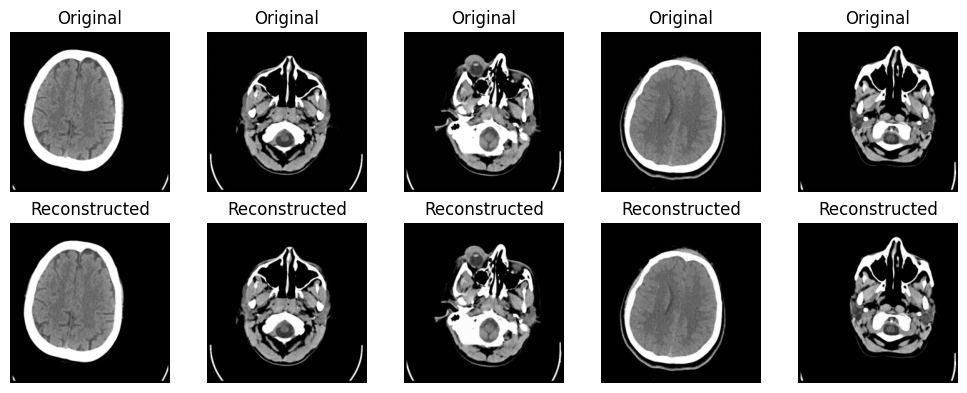

In [ ]:
from math import sqrt
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ---- Evaluate on Test Set ---- #
# Reconstruct test images
reconstructed = model.predict(x_test, batch_size=8, verbose=1)

# MSE
mse_test = np.mean(np.square(x_test - reconstructed))

# RMSE
rmse_test = sqrt(mse_test)

# PSNR
psnr_test = tf.image.psnr(x_test, reconstructed, max_val=1.0).numpy().mean()

# SSIM
ssim_test = tf.image.ssim(x_test, reconstructed, max_val=1.0).numpy().mean()

# MS-SSIM
ms_ssim_test = tf.image.ssim_multiscale(x_test, reconstructed, max_val=1.0).numpy().mean()

print("\nTest Set Metrics:")
print(f" MSE     : {mse_test:.4f}")
print(f" RMSE    : {rmse_test:.4f}")
print(f" PSNR    : {psnr_test:.2f}")
print(f" SSIM    : {ssim_test:.4f}")
print(f" MS-SSIM : {ms_ssim_test:.4f}")

# ---- Visualize Original vs Reconstructed ---- #
n = 5
plt.figure(figsize=(10, 4))
for i in range(n):
    # Original
    plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i].squeeze(), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
reconstructed = model.predict(x_test)
print(reconstructed.shape)

32/32 ━━━━━━━━━━━━━━━━━━━━ 52s 811ms/step
(1004, 256, 256, 1)


In [ ]:
import numpy as np
import tensorflow as tf
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def evaluate_model(model, x_test):
    psnr_scores = []
    ssim_scores = []
    msssim_scores = []

    # Get model predictions
    reconstructions = model.predict(x_test, batch_size=8)

    for i in range(len(x_test)):
        original = x_test[i].squeeze()         # (H, W)
        reconstructed = reconstructions[i].squeeze()

        # Convert to float64 for skimage metrics
        original = original.astype(np.float64)
        reconstructed = reconstructed.astype(np.float64)

        # PSNR
        psnr_val = psnr(original, reconstructed, data_range=1.0)
        psnr_scores.append(psnr_val)

        # SSIM
        ssim_val = ssim(original, reconstructed, data_range=1.0)
        ssim_scores.append(ssim_val)

        # MS-SSIM (TensorFlow expects batch dimension)
        original_tf = tf.convert_to_tensor(original[np.newaxis, ..., np.newaxis], dtype=tf.float32)
        reconstructed_tf = tf.convert_to_tensor(reconstructed[np.newaxis, ..., np.newaxis], dtype=tf.float32)
        msssim_val = tf.image.ssim_multiscale(original_tf, reconstructed_tf, max_val=1.0)
        msssim_scores.append(float(msssim_val.numpy()))

    # Average scores
    avg_psnr = np.mean(psnr_scores)
    avg_ssim = np.mean(ssim_scores)
    avg_msssim = np.mean(msssim_scores)

    return avg_psnr, avg_ssim, avg_msssim


# ✅ Example usage (matches your training variables)
avg_psnr, avg_ssim, avg_msssim = evaluate_model(model, x_test)

print("Average PSNR:", avg_psnr)
print("Average SSIM:", avg_ssim)
print("Average MS-SSIM:", avg_msssim)


126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step


/tmp/ipython-input-2373793076.py:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  msssim_scores.append(float(msssim_val.numpy()))


Average PSNR: 45.91413247685887
Average SSIM: 0.9889036020825329
Average MS-SSIM: 0.9995722261320548


In [ ]:
from google.colab import files
import zipfile
import os

# Upload file manually
uploaded = files.upload()

# Extract uploaded zip (replace with your filename if different)
zip_path = list(uploaded.keys())[0]  # gets the uploaded file name
extract_path = "/content/test_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(" Extracted to:", extract_path)
print("Contents:", os.listdir(extract_path))

Saving Crosstestdataset-20250828T175141Z-1-001.zip to Crosstestdataset-20250828T175141Z-1-001.zip
 Extracted to: /content/test_dataset
Contents: ['Crosstestdataset']


In [ ]:
# Correct folder paths
mri_path = "/content/test_dataset/Crosstestdataset/testdatasetmri"
ct_path  = "/content/test_dataset/Crosstestdataset/testdatasetCt"   # C is capital here

# Load MRI and CT test sets
x_test_mri = load_images_from_folder(mri_path)
x_test_ct  = load_images_from_folder(ct_path)

print(" MRI shape:", x_test_mri.shape)
print(" CT shape:", x_test_ct.shape)

 MRI shape: (1000, 256, 256)
 CT shape: (1000, 256, 256)


MRI shape: (1000, 256, 256)
CT shape : (1000, 256, 256)

 Evaluating on MRI dataset...
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step
 MRI Results:
   MSE   : 0.000038
   RMSE  : 0.006090
   PSNR  : 44.47 dB
   SSIM  : 0.9841
   MSSIM : 0.9841


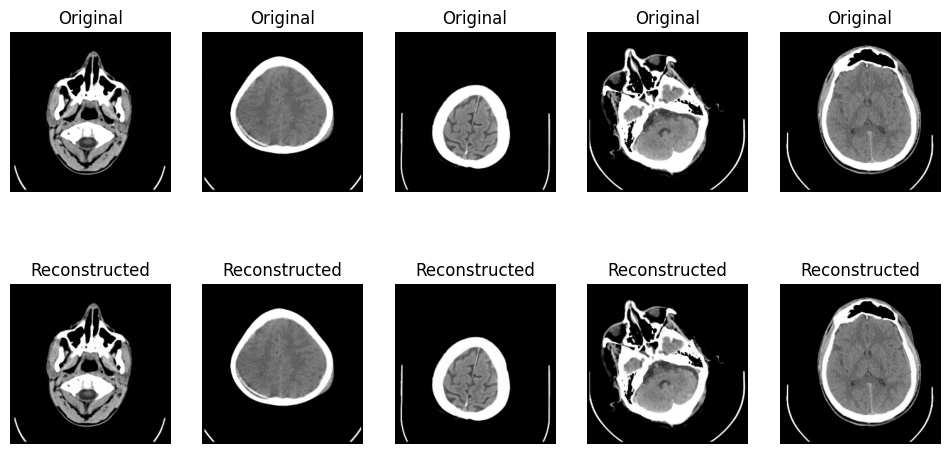


 Evaluating on CT dataset...
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 144ms/step
 CT Results:
   MSE   : 0.000022
   RMSE  : 0.004575
   PSNR  : 47.01 dB
   SSIM  : 0.9925
   MSSIM : 0.9925


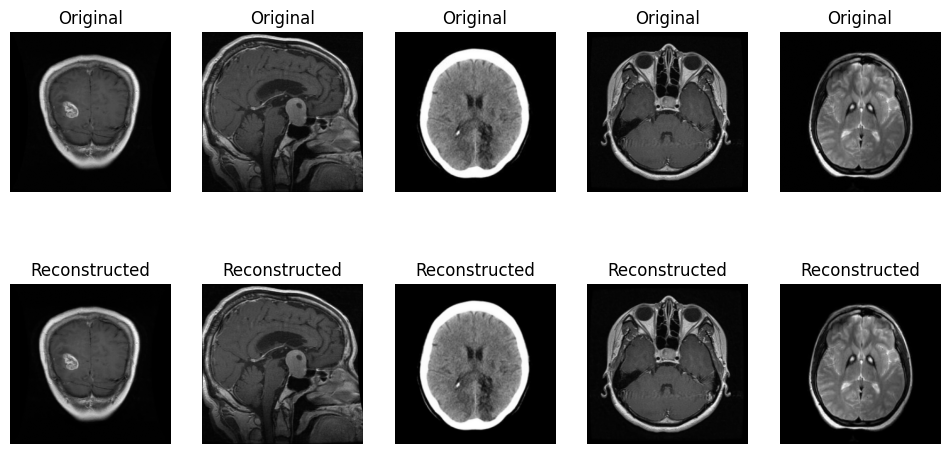

In [ ]:
import os
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim
from math import log10, sqrt
import matplotlib.pyplot as plt

# ---------- Load & Preprocess ----------
def load_images_from_folder(folder, target_size=(256, 256)):
    images = []
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # grayscale
        if img is not None:
            img = cv2.resize(img, target_size)  # resize to 256x256
            img = img.astype("float32") / 255.0  # normalize [0,1]
            images.append(img)
    return np.array(images)

# ---------- Metrics ----------
def calculate_mse(original, reconstructed):
    return np.mean((original - reconstructed) ** 2)

def calculate_rmse(original, reconstructed):
    return sqrt(calculate_mse(original, reconstructed))

def calculate_psnr(original, reconstructed):
    mse_val = calculate_mse(original, reconstructed)
    if mse_val == 0:
        return 100
    max_pixel = 1.0
    return 20 * log10(max_pixel / sqrt(mse_val))

def calculate_ssim(original, reconstructed):
    return ssim(original, reconstructed, data_range=1.0)

def evaluate_dataset(model, x_test, dataset_name, show_samples=True):
    print(f"\n Evaluating on {dataset_name} dataset...")

    if len(x_test.shape) == 3:
        x_test = np.expand_dims(x_test, axis=-1)  # add channel dim

    reconstructed = model.predict(x_test, verbose=1)

    mse_vals, rmse_vals, psnr_vals, ssim_vals = [], [], [], []

    for i in range(len(x_test)):
        orig = x_test[i].squeeze()
        rec  = reconstructed[i].squeeze()

        mse_vals.append(calculate_mse(orig, rec))
        rmse_vals.append(calculate_rmse(orig, rec))
        psnr_vals.append(calculate_psnr(orig, rec))
        ssim_vals.append(calculate_ssim(orig, rec))

    # MSSIM = mean SSIM across dataset
    mssim_val = np.mean(ssim_vals)

    print(f" {dataset_name} Results:")
    print(f"   MSE   : {np.mean(mse_vals):.6f}")
    print(f"   RMSE  : {np.mean(rmse_vals):.6f}")
    print(f"   PSNR  : {np.mean(psnr_vals):.2f} dB")
    print(f"   SSIM  : {np.mean(ssim_vals):.4f}")
    print(f"   MSSIM : {mssim_val:.4f}")

    # Show a few sample results
    if show_samples:
        n = 5
        plt.figure(figsize=(12, 6))
        for i in range(n):
            idx = np.random.randint(0, len(x_test))
            orig = x_test[idx].squeeze()
            rec  = reconstructed[idx].squeeze()

            plt.subplot(2, n, i+1)
            plt.imshow(orig, cmap="gray")
            plt.title("Original")
            plt.axis("off")

            plt.subplot(2, n, n+i+1)
            plt.imshow(rec, cmap="gray")
            plt.title("Reconstructed")
            plt.axis("off")
        plt.show()

# ---------- Load datasets ----------
mri_path = "/content/test_dataset/Crosstestdataset/testdatasetmri"
ct_path  = "/content/test_dataset/Crosstestdataset/testdatasetCt"

x_test_mri = load_images_from_folder(mri_path, target_size=(256, 256))
x_test_ct  = load_images_from_folder(ct_path,  target_size=(256, 256))

print("MRI shape:", x_test_mri.shape)
print("CT shape :", x_test_ct.shape)

# ---------- Run evaluation ----------
evaluate_dataset(model, x_test_mri, "MRI")
evaluate_dataset(model, x_test_ct,  "CT")


In [ ]:
x_test_overall = np.concatenate((x_test_mri, x_test_ct), axis=0)
print("Overall test set shape:", x_test_overall.shape)
evaluate_dataset(model, x_test_overall, "Overall (MRI + CT)")

Overall test set shape: (2000, 256, 256)
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step

Overall (MRI + CT) Results:
  MSE   : 0.000025
  RMSE  : 0.004781
  PSNR  : 46.73 dB
  SSIM  : 0.9964
  MSSIM : 0.9964


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from math import sqrt
import os
from tensorflow.keras.models import load_model

# --- Load previously saved model (safe copy) ---
model_path = '/content/drive/MyDrive/unetpp_autoencoder.h5'
model = load_model(model_path, compile=False)

# Re-compile
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='mse', metrics=['mae'])

# --- NEW MODEL SAVE PATH (different file, will overwrite each epoch) ---
new_model_path = '/content/drive/MyDrive/unetpp_autoencoder_continued.h5'

# --- Callback for metrics + CSV logging ---
class TrainMetricsCallback(tf.keras.callbacks.Callback):
    def __init__(self, x_train, sample_size=500, model_file=new_model_path, csv_path=None):
        self.x_train = x_train
        self.sample_size = sample_size
        self.model_file = model_file
        self.csv_path = csv_path if csv_path else model_file.replace(".h5", "_metrics.csv")

        # Initialize history
        self.history = {"epoch": [], "mse": [], "rmse": [], "psnr": [], "ssim": [], "ms_ssim": []}

        # Create CSV with headers (overwrite if already exists)
        pd.DataFrame(self.history).to_csv(self.csv_path, index=False)

    def on_epoch_end(self, epoch, logs=None):
        idx = np.random.choice(len(self.x_train), self.sample_size, replace=False)
        x_sample = self.x_train[idx]

        # Predict
        recon = self.model.predict(x_sample, batch_size=8, verbose=0)

        # Metrics
        mse_val = np.mean(np.square(x_sample - recon))
        rmse_val = sqrt(mse_val)
        psnr_val = tf.image.psnr(x_sample, recon, max_val=1.0).numpy().mean()
        ssim_val = tf.image.ssim(x_sample, recon, max_val=1.0).numpy().mean()
        ms_ssim_val = tf.image.ssim_multiscale(x_sample, recon, max_val=1.0).numpy().mean()

        # Save to history
        self.history["epoch"].append(epoch + 1)
        self.history["mse"].append(mse_val)
        self.history["rmse"].append(rmse_val)
        self.history["psnr"].append(psnr_val)
        self.history["ssim"].append(ssim_val)
        self.history["ms_ssim"].append(ms_ssim_val)

        # Save/overwrite NEW model file
        self.model.save(self.model_file)

        # Save metrics (npy backup)
        np.save(self.model_file.replace(".h5", "_metrics.npy"), self.history)

        # Append to CSV
        new_row = {
            "epoch": epoch + 1,
            "mse": mse_val,
            "rmse": rmse_val,
            "psnr": psnr_val,
            "ssim": ssim_val,
            "ms_ssim": ms_ssim_val
        }
        pd.DataFrame([new_row]).to_csv(self.csv_path, mode="a", header=False, index=False)

        print(f"\nEpoch {epoch+1} --> "
              f"MSE: {mse_val:.4f}, RMSE: {rmse_val:.4f}, "
              f"PSNR: {psnr_val:.2f}, SSIM: {ssim_val:.4f}, MS-SSIM: {ms_ssim_val:.4f}")


# --- Continue Training for 20 epochs ---
metrics_callback = TrainMetricsCallback(
    x_train,
    sample_size=500,
    model_file=new_model_path,  # ensure it writes to the new file
    csv_path="/content/drive/MyDrive/unetpp_train_metrics50.csv"
)

history = model.fit(
    x_train, x_train,
    epochs=20,
    batch_size=8,
    callbacks=[metrics_callback]
)

# Access metrics after training
train_metric_history_20 = metrics_callback.history


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 6.3581e-05 - mae: 0.0044


Epoch 1 --> MSE: 0.0000, RMSE: 0.0056, PSNR: 45.97, SSIM: 0.9878, MS-SSIM: 0.9996
500/500 ━━━━━━━━━━━━━━━━━━━━ 154s 225ms/step - loss: 6.3589e-05 - mae: 0.0044
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 6.7106e-05 - mae: 0.0046


Epoch 2 --> MSE: 0.0000, RMSE: 0.0058, PSNR: 45.95, SSIM: 0.9939, MS-SSIM: 0.9997
500/500 ━━━━━━━━━━━━━━━━━━━━ 100s 190ms/step - loss: 6.7070e-05 - mae: 0.0046
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 5.8955e-05 - mae: 0.0043


Epoch 3 --> MSE: 0.0000, RMSE: 0.0058, PSNR: 46.58, SSIM: 0.9937, MS-SSIM: 0.9996
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 190ms/step - loss: 5.8982e-05 - mae: 0.0043
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 5.1345e-05 - mae: 0.0041


Epoch 4 --> MSE: 0.0000, RMSE: 0.0055, PSNR: 47.09, SSIM: 0.9929, MS-SSIM: 0.9996
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 189ms/step - loss: 5.1332e-05 - mae: 0.0041
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 4.5079e-05 - mae: 0.0039

...


Epoch 16 --> MSE: 0.0000, RMSE: 0.0047, PSNR: 48.51, SSIM: 0.9965, MS-SSIM: 0.9997
500/500 ━━━━━━━━━━━━━━━━━━━━ 141s 189ms/step - loss: 3.9273e-05 - mae: 0.0036
Epoch 17/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 3.4648e-05 - mae: 0.0034


Epoch 17 --> MSE: 0.0000, RMSE: 0.0048, PSNR: 47.42, SSIM: 0.9934, MS-SSIM: 0.9997
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 190ms/step - loss: 3.4654e-05 - mae: 0.0034
Epoch 18/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 3.3567e-05 - mae: 0.0034


Epoch 18 --> MSE: 0.0000, RMSE: 0.0048, PSNR: 48.34, SSIM: 0.9954, MS-SSIM: 0.9997
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 190ms/step - loss: 3.3566e-05 - mae: 0.0034
Epoch 19/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 3.5052e-05 - mae: 0.0035


Epoch 19 --> MSE: 0.0000, RMSE: 0.0059, PSNR: 45.86, SSIM: 0.9859, MS-SSIM: 0.9996
500/500 ━━━━━━━━━━━━━━━━━━━━ 94s 189ms/step - loss: 3.5044e-05 - mae: 0.0035
Epoch 20/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 3.1161e-05 - mae: 0.0033


Epoch 20 --> MSE: 0.0000, RMSE: 0.0055, PSNR: 46.62, SSIM: 0.9966, MS-SSIM: 0.9997
500/500 ━━━━━━━━━━━━━━━━━━━━ 95s 189ms/step - loss: 3.1164e-05 - mae: 0.0033


In [ ]:
import numpy as np
from math import sqrt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# ---- Step 1: Predict on x_test ----
reconstructed = model.predict(x_test, batch_size=8, verbose=1)

# ---- Step 2: Initialize metric lists ----
mse_values, rmse_values, psnr_values, ssim_values = [], [], [], []

# ---- Step 3: Compute metrics ----
for orig, recon in zip(x_test, reconstructed):
    orig, recon = orig.squeeze(), recon.squeeze()

    mse_val = np.mean((orig - recon) ** 2)
    mse_values.append(mse_val)
    rmse_values.append(sqrt(mse_val))
    psnr_values.append(psnr(orig, recon, data_range=1.0))
    ssim_values.append(ssim(orig, recon, data_range=1.0))

# ---- Step 4: Compute Mean SSIM (MSSIM) ----
mssim = np.mean(ssim_values)

# ---- Step 5: Print results including MSSIM ----
print("\n---- Test Dataset Results ----")
print(f"Average MSE   : {np.mean(mse_values):.6f}")
print(f"Average RMSE  : {np.mean(rmse_values):.6f}")
print(f"Average PSNR  : {np.mean(psnr_values):.2f} dB")
print(f"Average SSIM  : {np.mean(ssim_values):.4f}")
print(f"Mean SSIM(MSSIM) : {mssim:.4f}")


126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step

---- Test Dataset Results ----
Average MSE   : 0.000031
Average RMSE  : 0.005042
Average PSNR  : 46.54 dB
Average SSIM  : 0.9966
Mean SSIM(MSSIM) : 0.9966


In [ ]:
import os
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim
from math import log10, sqrt
from tensorflow.keras.models import load_model
from google.colab import drive

# ---------- Mount Drive ----------
drive.mount('/content/drive')

# ---------- Load model ----------
model_path = "/content/drive/MyDrive/unetpp_autoencoder_continued.h5"
model = load_model(model_path, compile=False)
print("✅ Model loaded successfully!")

# ---------- Load & Preprocess ----------
def load_images_from_folder(folder, target_size=(256, 256)):
    images = []
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, target_size)
            img = img.astype("float32") / 255.0
            images.append(img)
    return np.array(images)

# ---------- Metrics ----------
def calculate_mse(original, reconstructed):
    return np.mean((original - reconstructed) ** 2)

def calculate_rmse(original, reconstructed):
    return sqrt(calculate_mse(original, reconstructed))

def calculate_psnr(original, reconstructed):
    mse_val = calculate_mse(original, reconstructed)
    if mse_val == 0:
        return 100
    return 20 * log10(1.0 / sqrt(mse_val))

def calculate_ssim(original, reconstructed):
    return ssim(original, reconstructed, data_range=1.0)

def evaluate_dataset(model, x_test, dataset_name):
    if len(x_test.shape) == 3:
        x_test = np.expand_dims(x_test, axis=-1)

    reconstructed = model.predict(x_test, verbose=1)

    mse_vals, rmse_vals, psnr_vals, ssim_vals = [], [], [], []

    for i in range(len(x_test)):
        orig = x_test[i].squeeze()
        rec  = reconstructed[i].squeeze()
        mse_vals.append(calculate_mse(orig, rec))
        rmse_vals.append(calculate_rmse(orig, rec))
        psnr_vals.append(calculate_psnr(orig, rec))
        ssim_vals.append(calculate_ssim(orig, rec))

    mssim_val = np.mean(ssim_vals)

    print(f"\n{dataset_name} Results:")
    print(f"  MSE   : {np.mean(mse_vals):.6f}")
    print(f"  RMSE  : {np.mean(rmse_vals):.6f}")
    print(f"  PSNR  : {np.mean(psnr_vals):.2f} dB")
    print(f"  SSIM  : {np.mean(ssim_vals):.4f}")
    print(f"  MSSIM : {mssim_val:.4f}")

# ---------- Load datasets ----------
mri_path = "/content/test_dataset/Crosstestdataset/testdatasetmri"
ct_path  = "/content/test_dataset/Crosstestdataset/testdatasetCt"

x_test_mri = load_images_from_folder(mri_path)
x_test_ct  = load_images_from_folder(ct_path)

print("MRI shape:", x_test_mri.shape)
print("CT shape :", x_test_ct.shape)

# ---------- Combine MRI + CT ----------
x_test_overall = np.concatenate((x_test_mri, x_test_ct), axis=0)
print("Overall test set shape:", x_test_overall.shape)

# ---------- Run evaluation ----------
evaluate_dataset(model, x_test_mri, "MRI")
evaluate_dataset(model, x_test_ct,  "CT")
evaluate_dataset(model, x_test_overall, "Overall (MRI + CT)")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model loaded successfully!
MRI shape: (1000, 256, 256)
CT shape : (1000, 256, 256)
Overall test set shape: (2000, 256, 256)
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 374ms/step

MRI Results:
  MSE   : 0.000030
  RMSE  : 0.005417
  PSNR  : 45.49 dB
  SSIM  : 0.9963
  MSSIM : 0.9963
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 145ms/step

CT Results:
  MSE   : 0.000019
  RMSE  : 0.004144
  PSNR  : 47.98 dB
  SSIM  : 0.9965
  MSSIM : 0.9965
63/63 ━━━━━━━━━━━━━━━━━━━━ 33s 537ms/step

Overall (MRI + CT) Results:
  MSE   : 0.000025
  RMSE  : 0.004781
  PSNR  : 46.73 dB
  SSIM  : 0.9964
  MSSIM : 0.9964


In [ ]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.output.shape)

0 input_layer (None, 256, 256, 1)
1 separable_conv2d (None, 256, 256, 64)
2 batch_normalization (None, 256, 256, 64)
3 activation (None, 256, 256, 64)
4 separable_conv2d_1 (None, 256, 256, 64)
5 batch_normalization_1 (None, 256, 256, 64)
6 activation_1 (None, 256, 256, 64)
7 max_pooling2d (None, 128, 128, 64)
8 separable_conv2d_2 (None, 128, 128, 128)
9 batch_normalization_2 (None, 128, 128, 128)
10 activation_2 (None, 128, 128, 128)
11 separable_conv2d_3 (None, 128, 128, 128)
12 batch_normalization_3 (None, 128, 128, 128)
13 activation_3 (None, 128, 128, 128)
14 max_pooling2d_1 (None, 64, 64, 128)
15 separable_conv2d_4 (None, 64, 64, 128)
16 batch_normalization_4 (None, 64, 64, 128)
17 activation_4 (None, 64, 64, 128)
18 separable_conv2d_5 (None, 64, 64, 128)
19 batch_normalization_5 (None, 64, 64, 128)
20 activation_5 (None, 64, 64, 128)
21 max_pooling2d_2 (None, 32, 32, 128)
22 separable_conv2d_6 (None, 32, 32, 128)
23 batch_normalization_6 (None, 32, 32, 128)
24 activation_6 (None,

In [ ]:
from tensorflow.keras.models import load_model

# Path to your saved model
model_path = "/content/drive/MyDrive/unetpp_autoencoder_continued.h5"

# Load model
model = load_model(model_path, compile=False)
print("✅ Model loaded successfully!")

# Print all layer details
for i, layer in enumerate(model.layers):
    try:
        print(f"{i}: {layer.name} → {layer.output.shape}")
    except Exception as e:
        print(f"{i}: {layer.name} → (output shape not available: {e})")


✅ Model loaded successfully!
0: input_layer → (None, 256, 256, 1)
1: separable_conv2d → (None, 256, 256, 64)
2: batch_normalization → (None, 256, 256, 64)
3: activation → (None, 256, 256, 64)
4: separable_conv2d_1 → (None, 256, 256, 64)
5: batch_normalization_1 → (None, 256, 256, 64)
6: activation_1 → (None, 256, 256, 64)
7: max_pooling2d → (None, 128, 128, 64)
8: separable_conv2d_2 → (None, 128, 128, 128)
9: batch_normalization_2 → (None, 128, 128, 128)
10: activation_2 → (None, 128, 128, 128)
11: separable_conv2d_3 → (None, 128, 128, 128)
12: batch_normalization_3 → (None, 128, 128, 128)
13: activation_3 → (None, 128, 128, 128)
14: max_pooling2d_1 → (None, 64, 64, 128)
15: separable_conv2d_4 → (None, 64, 64, 128)
16: batch_normalization_4 → (None, 64, 64, 128)
17: activation_4 → (None, 64, 64, 128)
18: separable_conv2d_5 → (None, 64, 64, 128)
19: batch_normalization_5 → (None, 64, 64, 128)
20: activation_5 → (None, 64, 64, 128)
21: max_pooling2d_2 → (None, 32, 32, 128)
22: separable_

In [ ]:
import tensorflow as tf
import numpy as np
import time
from tensorflow.keras.models import load_model

# ✅ Load your model
model_path = "/content/drive/MyDrive/unetpp_autoencoder_continued.h5"
model = load_model(model_path, compile=False)
print("✅ Model loaded successfully!")

# ✅ Show summary (to confirm bottleneck layer name and shape)
model.summary()

# ---- Get encoder bottleneck output ----
# Let's find the encoder bottleneck layer (usually smallest spatial dim, e.g., 8x8x32)
encoder_layer_name = None
for i, layer in enumerate(model.layers):
    if hasattr(layer, "output_shape"):
        if layer.output_shape == (None, 8, 8, 32):   # match bottleneck
            encoder_layer_name = layer.name
            print(f"🎯 Found encoder bottleneck layer: {encoder_layer_name}")
            break

if encoder_layer_name is None:
    print("❌ Bottleneck layer (8x8x32) not found automatically. Please check model summary.")

# ✅ Build encoder model (input → bottleneck)
from tensorflow.keras import Model
encoder = Model(inputs=model.input, outputs=model.get_layer(encoder_layer_name).output)
print("✅ Encoder model constructed!")

# ---- Test Input ----
# Example: 128x128 grayscale or RGB (adjust shape to your data)
dummy_input = np.random.rand(1, 128, 128, 1).astype(np.float32)  # shape depends on your model

# ---- Timing: GPU vs CPU ----
def measure_time(run_on_gpu=True):
    if run_on_gpu:
        device = "/GPU:0"
    else:
        device = "/CPU:0"

    with tf.device(device):
        # Warm-up (to avoid first-run overhead)
        _ = encoder(dummy_input, training=False)

        start = time.time()
        for _ in range(100):  # run multiple times to average
            _ = encoder(dummy_input, training=False)
        end = time.time()

    avg_time = (end - start) / 100
    return avg_time

# Measure
gpu_time = measure_time(run_on_gpu=True)
cpu_time = measure_time(run_on_gpu=False)

print(f"⚡ Average encoding time on GPU: {gpu_time:.6f} sec per image")
print(f"🐢 Average encoding time on CPU: {cpu_time:.6f} sec per image")

# ---- Check bottleneck size ----
bottleneck_output = encoder(dummy_input)
print("🔹 Bottleneck shape:", bottleneck_output.shape)


✅ Model loaded successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 256, 256,  │        137 │ input_layer[0][0] │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 256, 256,  │      4,736 │ activation[0][0]  │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 128, 128,  │      8,896 │ max_pooling2d[0]… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_3  │ (None, 128, 128,  │     17,664 │ activation_2[0][… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_4  │ (None, 64, 64,    │     17,664 │ max_pooling2d_1[… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ separable_conv2d

 Total params: 309,194 (1.18 MB)

 Trainable params: 304,970 (1.16 MB)

 Non-trainable params: 4,224 (16.50 KB)

❌ Bottleneck layer (8x8x32) not found automatically. Please check model summary.


ValueError: Provide either a layer name or layer index at `get_layer`.

In [ ]:
from tensorflow.keras.models import load_model

# Load your saved model
model_path = "/content/drive/MyDrive/unetpp_autoencoder_continued.h5"
model = load_model(model_path, compile=False)
print("✅ Model loaded successfully!\n")

# Print all layers with index, name, and output shape
for i, layer in enumerate(model.layers):
    try:
        print(i, layer.name, layer.output.shape)
    except:
        print(i, layer.name, "⚠️ No output shape")


✅ Model loaded successfully!

0 input_layer (None, 256, 256, 1)
1 separable_conv2d (None, 256, 256, 64)
2 batch_normalization (None, 256, 256, 64)
3 activation (None, 256, 256, 64)
4 separable_conv2d_1 (None, 256, 256, 64)
5 batch_normalization_1 (None, 256, 256, 64)
6 activation_1 (None, 256, 256, 64)
7 max_pooling2d (None, 128, 128, 64)
8 separable_conv2d_2 (None, 128, 128, 128)
9 batch_normalization_2 (None, 128, 128, 128)
10 activation_2 (None, 128, 128, 128)
11 separable_conv2d_3 (None, 128, 128, 128)
12 batch_normalization_3 (None, 128, 128, 128)
13 activation_3 (None, 128, 128, 128)
14 max_pooling2d_1 (None, 64, 64, 128)
15 separable_conv2d_4 (None, 64, 64, 128)
16 batch_normalization_4 (None, 64, 64, 128)
17 activation_4 (None, 64, 64, 128)
18 separable_conv2d_5 (None, 64, 64, 128)
19 batch_normalization_5 (None, 64, 64, 128)
20 activation_5 (None, 64, 64, 128)
21 max_pooling2d_2 (None, 32, 32, 128)
22 separable_conv2d_6 (None, 32, 32, 128)
23 batch_normalization_6 (None, 32, 3

In [ ]:
from tensorflow.keras.models import load_model, Model

# Load model
model_path = "/content/drive/MyDrive/unetpp_autoencoder_continued.h5"
model = load_model(model_path, compile=False)
print("✅ Model loaded successfully!")

# Bottleneck layer name from summary
encoder_layer_name = "activation_11"

# Build encoder (input → bottleneck)
encoder = Model(inputs=model.input, outputs=model.get_layer(encoder_layer_name).output)

# Print encoder output shape
print("🔹 Encoder output shape:", encoder.output.shape)


✅ Model loaded successfully!
🔹 Encoder output shape: (None, 8, 8, 32)


In [ ]:
bottleneck_layer = model.layers[41]

# Define a new model that outputs latent vectors
bottleneck_model = tf.keras.Model(inputs=model.input, outputs=bottleneck_layer.output)

# Get latent compressed representation for test images
latent_vectors = bottleneck_model.predict(x_test)
print("Latent vectors shape:", latent_vectors.shape)

32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 391ms/step
Latent vectors shape: (1004, 8, 8, 32)


In [ ]:
import numpy as np
num_elements = np.prod(latent_vectors.shape[1:])
bytes_per_element = 4  # float32 size in bytes

compressed_size_bytes = num_elements * bytes_per_element
original_size_bytes = 256 * 256 * 1 * bytes_per_element  # grayscale 256x256 image

compression_ratio = original_size_bytes / compressed_size_bytes

print(f"Compressed size per image: {compressed_size_bytes} bytes")
print(f"Original size per image: {original_size_bytes} bytes")
print(f"Compression ratio: {compression_ratio:.2f}:1")


Compressed size per image: 8192 bytes
Original size per image: 262144 bytes
Compression ratio: 32.00:1


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/unetpp_autoencoder_continued.h5", compile=False)


In [ ]:
!find /content/drive/MyDrive/ -name "*.h5"


/content/drive/MyDrive/unetpp_autoencoder_continued.h5
/content/drive/MyDrive/unetpp_autoencoder.h5


In [ ]:
total_params = model.count_params()
print("Total Trainable Params (Million):", total_params / 1e6)

Total Trainable Params (Million): 0.309194


In [ ]:
import os
model_path = "/content/drive/MyDrive/unetpp_autoencoder_continued.h5"
size_mb = os.path.getsize(model_path) / (1024 * 1024)
print("Model size:", size_mb, "MB")

Model size: 3.8742828369140625 MB


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.models import load_model, Model

# --- Load full model ---
model_path = "/content/drive/MyDrive/unetpp_autoencoder_continued.h5"
model = load_model(model_path, compile=False)
print("✅ Model loaded!")

# --- Find bottleneck layer (output shape 8x8x32) ---
bottleneck_layer = None
for layer in model.layers:
    try:
        if tuple(layer.output.shape[1:]) == (8, 8, 32):  # skip batch dim
            bottleneck_layer = layer
            break
    except Exception:
        continue  # skip InputLayer or others without .output

if bottleneck_layer is None:
    raise ValueError("❌ No layer found with output shape (8, 8, 32)")

print("✅ Bottleneck layer found:", bottleneck_layer.name, bottleneck_layer.output.shape)

# --- Build encoder: input → bottleneck ---
encoder = Model(inputs=model.input, outputs=bottleneck_layer.output, name="encoder")
encoder.save("/content/encoder.keras")
print("✅ Encoder saved at /content/encoder.keras")

# --- Show encoder size ---
size_mb = os.path.getsize("/content/encoder.keras") / (1024 * 1024)
print(f"📦 Encoder size: {size_mb:.2f} MB")


✅ Model loaded!
✅ Bottleneck layer found: separable_conv2d_10 (None, 8, 8, 32)
✅ Encoder saved at /content/encoder.keras
📦 Encoder size: 0.60 MB


In [ ]:
import tensorflow as tf
import os

# Load full model
model = tf.keras.models.load_model("/content/drive/MyDrive/unetpp_autoencoder_continued.h5", compile=False)

# Name of the bottleneck layer (with output 8x8x32)
bottleneck_layer_name = "separable_conv2d_10"   # change if needed
bottleneck_output = model.get_layer(bottleneck_layer_name).output

# ✅ Encoder: from input → bottleneck
encoder = tf.keras.Model(inputs=model.input, outputs=bottleneck_output, name="encoder")
encoder.save("/content/encoder.keras")  # modern format

# ✅ Decoder: rebuild graph (ignore skip connections)
decoder_input = tf.keras.Input(shape=(8, 8, 32))  # bottleneck shape
x = decoder_input

take_layers = False
for layer in model.layers:
    if layer.name == bottleneck_layer_name:
        take_layers = True
        continue
    if take_layers:
        try:
            # Apply only if layer takes a single input (skip connections ignored)
            if isinstance(layer.input, list):
                # Skip concatenate/merge layers
                continue
            x = layer(x)
        except Exception as e:
            print(f"Skipping layer {layer.name} due to {e}")
            continue

decoder = tf.keras.Model(inputs=decoder_input, outputs=x, name="decoder")
decoder.save("/content/decoder.keras")

# ✅ Sizes
print("Encoder size MB:", os.path.getsize("/content/encoder.keras")/(1024*1024))
print("Decoder size MB:", os.path.getsize("/content/decoder.keras")/(1024*1024))


Skipping layer separable_conv2d_12 due to Input 0 of layer "separable_conv2d_12" is incompatible with the layer: expected axis -1 of input shape to have value 96, but received input with shape (None, 16, 16, 32)
Skipping layer batch_normalization_12 due to Input 0 of layer "batch_normalization_12" is incompatible with the layer: expected axis -1 of input shape to have value 64, but received input with shape (None, 16, 16, 32)
Skipping layer separable_conv2d_13 due to Input 0 of layer "separable_conv2d_13" is incompatible with the layer: expected axis -1 of input shape to have value 64, but received input with shape (None, 16, 16, 32)
Skipping layer batch_normalization_13 due to Input 0 of layer "batch_normalization_13" is incompatible with the layer: expected axis -1 of input shape to have value 64, but received input with shape (None, 16, 16, 32)
Skipping layer separable_conv2d_14 due to Input 0 of layer "separable_conv2d_14" is incompatible with the layer: expected axis -1 of input s

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 256, 256,  │        137 │ input_layer[0][0] │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 256, 256,  │      4,736 │ activation[0][0]  │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 128, 128,  │      8,896 │ max_pooling2d[0]… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_3  │ (None, 128, 128,  │     17,664 │ activation_2[0][… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_4  │ (None, 64, 64,    │     17,664 │ max_pooling2d_1[… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ separable_conv2d

 Total params: 309,194 (1.18 MB)

 Trainable params: 304,970 (1.16 MB)

 Non-trainable params: 4,224 (16.50 KB)

In [ ]:
from tensorflow.keras.models import load_model, Model
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Load your saved model (update path if needed)
full_model_path = "/content/drive/MyDrive/unetpp_autoencoder_continued.h5"
full_model = load_model(full_model_path)

# 3. Encoder: from input → activation_11 (bottleneck)
encoder = Model(
    inputs=full_model.input,
    outputs=full_model.get_layer("activation_11").output,
    name="encoder"
)

# 4. Decoder: input = bottleneck, output = final reconstruction
bottleneck_input = full_model.get_layer("activation_11").output
decoder_input = full_model.get_layer("activation_11").input

decoder = Model(
    inputs=full_model.get_layer("activation_11").output,
    outputs=full_model.output,
    name="decoder"
)

# 5. Save them to Drive
encoder_path = "/content/drive/MyDrive/encoder_8x8x32.h5"
decoder_path = "/content/drive/MyDrive/decoder_8x8x32.h5"

encoder.save(encoder_path)
decoder.save(decoder_path)

print("✅ Encoder and Decoder saved in Drive:")
print(f"Encoder: {encoder_path}")
print(f"Decoder: {decoder_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


TypeError: Could not locate function 'mse'. Make sure custom classes are decorated with `@keras.saving.register_keras_serializable()`. Full object config: {'module': 'keras.metrics', 'class_name': 'function', 'config': 'mse', 'registered_name': 'mse'}

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras import optimizers, losses, metrics

# Path to your model
full_model_path = "/content/drive/MyDrive/unetpp_autoencoder_continued.h5"

# Load without compiling
full_model = load_model(full_model_path, compile=False)

# Recompile manually
full_model.compile(
    optimizer=optimizers.Adam(1e-4),
    loss=losses.MeanSquaredError(),
    metrics=[metrics.MeanAbsoluteError()]
)

print("Model loaded and recompiled successfully ✅")


Model loaded and recompiled successfully ✅


In [ ]:
from tensorflow.keras.models import Model, load_model
from tensorflow.keras import optimizers, losses, metrics
import os

# 1. Path to your saved full model
full_model_path = "/content/drive/MyDrive/unetpp_autoencoder_continued.h5"

# 2. Load without compiling (fix for 'mse' error)
full_model = load_model(full_model_path, compile=False)

# 3. Recompile manually
full_model.compile(
    optimizer=optimizers.Adam(1e-4),
    loss=losses.MeanSquaredError(),
    metrics=[metrics.MeanAbsoluteError()]
)
print("✅ Full model loaded and compiled")

# 4. Check layer names (to identify bottleneck)
print("🔎 Layers in the model:")
for i, layer in enumerate(full_model.layers):
    print(i, layer.name, layer.output_shape)

# 👉 Replace "activation_11" with your actual bottleneck layer name
bottleneck_layer = "activation_11"

# 5. Build Encoder (input → bottleneck)
encoder = Model(inputs=full_model.input,
                outputs=full_model.get_layer(bottleneck_layer).output,
                name="encoder")

# 6. Build Decoder (bottleneck → output)
decoder_input = full_model.get_layer(bottleneck_layer).output
decoder_output = full_model.output
decoder = Model(inputs=decoder_input, outputs=decoder_output, name="decoder")

# 7. Save both models separately
save_dir = "/content/drive/MyDrive/split_models"
os.makedirs(save_dir, exist_ok=True)

encoder.save(os.path.join(save_dir, "encoder_8x8x32.h5"))
decoder.save(os.path.join(save_dir, "decoder_8x8x32.h5"))

print("✅ Encoder and Decoder saved in:", save_dir)


✅ Full model loaded and compiled
🔎 Layers in the model:


AttributeError: 'InputLayer' object has no attribute 'output_shape'

In [ ]:
print("🔎 Layers in the model:")
for i, layer in enumerate(full_model.layers):
    try:
        print(i, layer.name, layer.output.shape)
    except:
        print(i, layer.name, "⚠️ No output shape")


🔎 Layers in the model:
0 input_layer (None, 256, 256, 1)
1 separable_conv2d (None, 256, 256, 64)
2 batch_normalization (None, 256, 256, 64)
3 activation (None, 256, 256, 64)
4 separable_conv2d_1 (None, 256, 256, 64)
5 batch_normalization_1 (None, 256, 256, 64)
6 activation_1 (None, 256, 256, 64)
7 max_pooling2d (None, 128, 128, 64)
8 separable_conv2d_2 (None, 128, 128, 128)
9 batch_normalization_2 (None, 128, 128, 128)
10 activation_2 (None, 128, 128, 128)
11 separable_conv2d_3 (None, 128, 128, 128)
12 batch_normalization_3 (None, 128, 128, 128)
13 activation_3 (None, 128, 128, 128)
14 max_pooling2d_1 (None, 64, 64, 128)
15 separable_conv2d_4 (None, 64, 64, 128)
16 batch_normalization_4 (None, 64, 64, 128)
17 activation_4 (None, 64, 64, 128)
18 separable_conv2d_5 (None, 64, 64, 128)
19 batch_normalization_5 (None, 64, 64, 128)
20 activation_5 (None, 64, 64, 128)
21 max_pooling2d_2 (None, 32, 32, 128)
22 separable_conv2d_6 (None, 32, 32, 128)
23 batch_normalization_6 (None, 32, 32, 128)

In [ ]:
from tensorflow.keras.models import Model, load_model
import tensorflow as tf

# 1. Load full model
full_model_path = "/content/drive/MyDrive/unetpp_autoencoder_continued.h5"
full_model = load_model(full_model_path, compile=False)

# 2. Identify bottleneck layer
bottleneck_layer = full_model.get_layer("activation_11")  # index 41

# 3. Build encoder model (input → bottleneck)
encoder = Model(inputs=full_model.input, outputs=bottleneck_layer.output)
encoder.summary()

# 4. Build decoder model (bottleneck input → final output)
decoder_input = tf.keras.Input(shape=bottleneck_layer.output.shape[1:])  # (8,8,32)
x = decoder_input
for layer in full_model.layers[42:]:   # layers after bottleneck
    x = layer(x)
decoder = Model(inputs=decoder_input, outputs=x)
decoder.summary()

# 5. Save both models
encoder.save("/content/drive/MyDrive/encoder_8x8x32.h5")
decoder.save("/content/drive/MyDrive/decoder_8x8x32.h5")

print("✅ Encoder and Decoder saved successfully in Drive")


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 256, 256, 64)   │           137 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 256, 256, 64)   │         4,736 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 128, 128, 128)  │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_3              │ (None, 128, 128, 128)  │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_4              │ (None, 64, 64, 128)    │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_5              │ (None, 64, 64, 128)    │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 124,585 (486.66 KB)

 Trainable params: 122,409 (478.16 KB)

 Non-trainable params: 2,176 (8.50 KB)

NotImplementedError: Exception encountered when calling Concatenate.call().

[1mIterating over a symbolic KerasTensor is not supported.[0m

Arguments received by Concatenate.call():
  • args=('<KerasTensor shape=(None, 16, 16, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1360>',)
  • kwargs=<class 'inspect._empty'>

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 256, 256,  │        137 │ input_layer[0][0] │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 256, 256,  │      4,736 │ activation[0][0]  │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 128, 128,  │      8,896 │ max_pooling2d[0]… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_3  │ (None, 128, 128,  │     17,664 │ activation_2[0][… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_4  │ (None, 64, 64,    │     17,664 │ max_pooling2d_1[… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ separable_conv2d

 Total params: 309,194 (1.18 MB)

 Trainable params: 304,970 (1.16 MB)

 Non-trainable params: 4,224 (16.50 KB)

In [ ]:
bottleneck_layer = model.layers[41]   # your latent space layer
bottleneck_model = tf.keras.Model(inputs=model.input, outputs=bottleneck_layer.output)

import time
start = time.time()
latent_vectors = bottleneck_model.predict(x_test, batch_size=8, verbose=1)
end = time.time()

print(f"Encoding time: {end - start:.2f} seconds")
print("Latent shape:", latent_vectors.shape)

126/126 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step
Encoding time: 10.77 seconds
Latent shape: (1004, 8, 8, 32)


In [ ]:
print(model.layers[41].name)


activation_11


In [ ]:
from tensorflow.keras import layers, models

# Latent space shape (bottleneck)
latent_shape = (8, 8, 32)
decoder_input = layers.Input(shape=latent_shape)

x = decoder_input
x = layers.Conv2DTranspose(64, (3,3), strides=2, padding="same", activation="relu")(x)  # 8 -> 16
x = layers.Conv2DTranspose(32, (3,3), strides=2, padding="same", activation="relu")(x)  # 16 -> 32
x = layers.Conv2DTranspose(16, (3,3), strides=2, padding="same", activation="relu")(x)  # 32 -> 64
x = layers.Conv2DTranspose(8, (3,3), strides=2, padding="same", activation="relu")(x)   # 64 -> 128
x = layers.Conv2DTranspose(4, (3,3), strides=2, padding="same", activation="relu")(x)   # 128 -> 256
decoder_output = layers.Conv2D(1, (3,3), activation="sigmoid", padding="same")(x)       # 256x256x1

decoder_model = models.Model(decoder_input, decoder_output)
decoder_model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 64)     │        18,496 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 16)     │         4,624 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 128, 128, 8)    │         1,160 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 256, 256, 4)    │           292 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 1)    │            37 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,073 (168.25 KB)

 Trainable params: 43,073 (168.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf

# Decoder for latent space (8, 8, 32)
decoder_input = tf.keras.Input(shape=(8, 8, 32))

x = tf.keras.layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(decoder_input)  # 16x16
x = tf.keras.layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)  # 32x32
x = tf.keras.layers.Conv2DTranspose(16, 3, strides=2, padding='same', activation='relu')(x)  # 64x64
x = tf.keras.layers.Conv2DTranspose(8, 3, strides=2, padding='same', activation='relu')(x)   # 128x128
x = tf.keras.layers.Conv2DTranspose(1, 3, strides=2, padding='same', activation='sigmoid')(x) # 256x256

decoder = tf.keras.Model(inputs=decoder_input, outputs=x)
decoder.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 16, 16, 64)     │        18,496 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 32, 32, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 64, 64, 16)     │         4,624 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 128, 128, 8)    │         1,160 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 256, 256, 1)    │            73 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,817 (167.25 KB)

 Trainable params: 42,817 (167.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import time

# latent_vectors is the bottleneck output you already computed
# shape = (num_samples, 8, 8, 32)
# decoder_model is your 8x8x32 → 256x256 decoder

start = time.time()
reconstructed = decoder_model.predict(latent_vectors, batch_size=8, verbose=1)
end = time.time()

decoding_time = end - start
print(f"Decoding time: {decoding_time:.2f} seconds")
print("Reconstructed shape:", reconstructed.shape)  # Expected: (num_samples, 256, 256, 1)


126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Decoding time: 2.60 seconds
Reconstructed shape: (1004, 256, 256, 1)


In [ ]:
import time
import numpy as np

# ----------------------------
# Assuming:
# latent_vectors -> your bottleneck features of shape (num_samples, 8, 8, 32)
# decoder_model   -> your decoder part of UNet++ as a separate Keras model
# ----------------------------

# Example: if latent_vectors not defined yet
# latent_vectors = model.predict(train_images)[1]  # if your model returns (reconstructed, bottleneck)

start_time = time.time()

# Decode from latent vectors
reconstructed = decoder_model.predict(latent_vectors, batch_size=8, verbose=1)

end_time = time.time()
decoding_time = end_time - start_time

print(f"Decoding time for {latent_vectors.shape[0]} images: {decoding_time:.2f} seconds")
print(f"Average decoding time per image: {decoding_time / latent_vectors.shape[0]:.4f} seconds")


126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Decoding time for 1004 images: 1.34 seconds
Average decoding time per image: 0.0013 seconds


In [ ]:
import numpy as np
import time

# Original image from x_test
img = x_test[0]  # shape: (256, 256) or (256,256,1)

# Make sure it has 4 dimensions: (1, 256, 256, 1)
if img.ndim == 2:
    single_image = img[np.newaxis, ..., np.newaxis]  # (1,256,256,1)
elif img.ndim == 3:
    single_image = img[np.newaxis, ...]  # already has channels
else:
    single_image = img  # already 4D

print("Single image shape:", single_image.shape)

Single image shape: (1, 256, 256, 1)


In [ ]:
import time

# Measure encoding time for a single image
start_enc = time.perf_counter()
latent_single = bottleneck_model.predict(single_image, verbose=0)  # Bottleneck output (8, 8, 32)
end_enc = time.perf_counter()

encoding_time_ms = (end_enc - start_enc) * 1000
print(f"Encoding time for 1 image: {encoding_time_ms:.2f} ms")
print("Latent shape:", latent_single.shape)  # Expected: (1, 8, 8, 32)


Encoding time for 1 image: 9950.79 ms
Latent shape: (1, 8, 8, 32)


In [ ]:
import time

# latent_vectors is the bottleneck output you already computed
# shape = (num_samples, 8, 8, 32)
# decoder_model is your 8x8x32 → 256x256 decoder

start = time.time()
reconstructed = decoder_model.predict(latent_vectors, batch_size=8, verbose=1)
end = time.time()

decoding_time = end - start
print(f"Decoding time: {decoding_time:.2f} seconds")
print("Reconstructed shape:", reconstructed.shape)  # Expected: (num_samples, 256, 256, 1)


126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Decoding time: 1.33 seconds
Reconstructed shape: (1004, 256, 256, 1)


In [ ]:
for i, layer in enumerate(model.layers):
    try:
        print(i, layer.name, layer.output_shape)
    except:
        print(i, layer.name, " (no static shape)")


0 input_layer  (no static shape)
1 separable_conv2d  (no static shape)
2 batch_normalization  (no static shape)
3 activation  (no static shape)
4 separable_conv2d_1  (no static shape)
5 batch_normalization_1  (no static shape)
6 activation_1  (no static shape)
7 max_pooling2d  (no static shape)
8 separable_conv2d_2  (no static shape)
9 batch_normalization_2  (no static shape)
10 activation_2  (no static shape)
11 separable_conv2d_3  (no static shape)
12 batch_normalization_3  (no static shape)
13 activation_3  (no static shape)
14 max_pooling2d_1  (no static shape)
15 separable_conv2d_4  (no static shape)
16 batch_normalization_4  (no static shape)
17 activation_4  (no static shape)
18 separable_conv2d_5  (no static shape)
19 batch_normalization_5  (no static shape)
20 activation_5  (no static shape)
21 max_pooling2d_2  (no static shape)
22 separable_conv2d_6  (no static shape)
23 batch_normalization_6  (no static shape)
24 activation_6  (no static shape)
25 separable_conv2d_7  (no sta

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt
import tensorflow as tf


# Select a single image
img = x_test[0]  # shape: (256,256) or (256,256,1)

# Ensure it has batch dimension: (1, 256, 256, 1)
if img.ndim == 2:
    single_image = img[np.newaxis, ..., np.newaxis]
elif img.ndim == 3:
    single_image = img[np.newaxis, ...]
else:
    single_image = img

print("Single image shape:", single_image.shape)

# ----------------------------
# Measure encoding time
# ----------------------------
start_enc = time.perf_counter()
latent_single = bottleneck_model.predict(single_image, verbose=0)  # 8x8x32
end_enc = time.perf_counter()

encoding_time_ms = (end_enc - start_enc) * 1000
print(f"Encoding time for 1 image: {encoding_time_ms:.2f} ms")
print("Latent shape:", latent_single.shape)

# ----------------------------
# Measure decoding time
# ----------------------------
start_dec = time.perf_counter()
reconstructed = decoder_model.predict(latent_single, verbose=0)  # shape: (1, 256, 256, 1)
end_dec = time.perf_counter()

decoding_time_ms = (end_dec - start_dec) * 1000
print(f"Decoding time for 1 image: {decoding_time_ms:.2f} ms")
print("Reconstructed image shape:", reconstructed.shape)


Single image shape: (1, 256, 256, 1)
Encoding time for 1 image: 85.25 ms
Latent shape: (1, 8, 8, 32)
Decoding time for 1 image: 73.15 ms
Reconstructed image shape: (1, 256, 256, 1)


In [ ]:
import tensorflow as tf
import os
import time
import numpy as np

# ----------------------------
# Force CPU (disable GPU)
# ----------------------------
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# ----------------------------
# Select a single image
# ----------------------------
img = x_test[0]  # shape: (256,256) or (256,256,1)
single_image = img[np.newaxis, ..., np.newaxis] if img.ndim == 2 else img[np.newaxis, ...]

print("Single image shape:", single_image.shape)

# ----------------------------
# Measure encoding time (CPU)
# ----------------------------
start_enc = time.perf_counter()
latent_single = bottleneck_model.predict(single_image, verbose=0)  # 8x8x32
end_enc = time.perf_counter()

encoding_time_ms = (end_enc - start_enc) * 1000
print(f"CPU Encoding time for 1 image: {encoding_time_ms:.2f} ms")
print("Latent shape:", latent_single.shape)

# ----------------------------
# Measure decoding time (CPU)
# ----------------------------
start_dec = time.perf_counter()
reconstructed = decoder_model.predict(latent_single, verbose=0)  # shape: (1,256,256,1)
end_dec = time.perf_counter()

decoding_time_ms = (end_dec - start_dec) * 1000
print(f"CPU Decoding time for 1 image: {decoding_time_ms:.2f} ms")
print("Reconstructed image shape:", reconstructed.shape)


Single image shape: (1, 256, 256, 1)
CPU Encoding time for 1 image: 304.42 ms
Latent shape: (1, 8, 8, 32)
CPU Decoding time for 1 image: 206.21 ms
Reconstructed image shape: (1, 256, 256, 1)


In [ ]:
import time
import os
import numpy as np

# Disable GPU
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# Ensure dataset shape is correct (add batch dimension if needed)
x_test_batch = x_test[..., np.newaxis] if x_test.ndim == 3 else x_test

# Measure encoding time
start_enc_all = time.perf_counter()
latent_all = bottleneck_model.predict(x_test_batch, verbose=1)
end_enc_all = time.perf_counter()

print(f"CPU Encoding time for whole dataset: {(end_enc_all - start_enc_all):.2f} seconds")


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step
CPU Encoding time for whole dataset: 2.92 seconds


In [ ]:
import os
import time
import numpy as np
import tensorflow as tf

# -----------------------------
# Force CPU usage
# -----------------------------
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# -----------------------------
# Ensure dataset shape
# -----------------------------
# x_test should have shape (num_samples, 256, 256, 1)
x_test_batch = x_test
if x_test_batch.ndim == 3:
    x_test_batch = x_test_batch[..., np.newaxis]  # add channel
print("Test dataset shape for CPU timing:", x_test_batch.shape)

# -----------------------------
# CPU Encoding Time
# -----------------------------
start_enc = time.perf_counter()
latent_all = bottleneck_model.predict(x_test_batch, batch_size=8, verbose=1)  # 8x8x32 bottleneck
end_enc = time.perf_counter()

encoding_time_sec = end_enc - start_enc
print(f"CPU Encoding time for whole dataset: {encoding_time_sec:.2f} seconds")
print("Latent shape:", latent_all.shape)  # Should be (num_samples, 8, 8, 32)

# -----------------------------
# CPU Decoding Time
# -----------------------------
start_dec = time.perf_counter()
reconstructed_all = decoder_model.predict(latent_all, batch_size=8, verbose=1)
end_dec = time.perf_counter()

decoding_time_sec = end_dec - start_dec
print(f"CPU Decoding time for whole dataset: {decoding_time_sec:.2f} seconds")
print("Reconstructed shape:", reconstructed_all.shape)  # Should be (num_samples, 256, 256, 1)

# -----------------------------
# Optional: per-image average
# -----------------------------
num_images = x_test_batch.shape[0]
print(f"Average CPU encoding time per image: {encoding_time_sec / num_images * 1000:.2f} ms")
print(f"Average CPU decoding time per image: {decoding_time_sec / num_images * 1000:.2f} ms")


Test dataset shape for CPU timing: (1004, 256, 256, 1)
126/126 ━━━━━━━━━━━━━━━━━━━━ 20s 88ms/step
CPU Encoding time for whole dataset: 21.32 seconds
Latent shape: (1004, 8, 8, 32)
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
CPU Decoding time for whole dataset: 0.84 seconds
Reconstructed shape: (1004, 256, 256, 1)
Average CPU encoding time per image: 21.23 ms
Average CPU decoding time per image: 0.84 ms


In [ ]:
import time
import os

# Disable GPU
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# Measure decoding time
start_dec_all = time.perf_counter()
reconstructed_all = decoder_model.predict(latent_all, verbose=1)  # Use your decoder/autoencoder
end_dec_all = time.perf_counter()

print(f"CPU Decoding time for whole dataset: {(end_dec_all - start_dec_all):.2f} seconds")
# Check latent vectors
print("Shape of latent_all:", latent_all.shape)
print("Number of latent vectors:", latent_all.shape[0])

# Check reconstructed images
print("Shape of reconstructed_all:", reconstructed_all.shape)
print("Number of reconstructed images:", reconstructed_all.shape[0])



32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
CPU Decoding time for whole dataset: 0.81 seconds
Shape of latent_all: (1004, 8, 8, 32)
Number of latent vectors: 1004
Shape of reconstructed_all: (1004, 256, 256, 1)
Number of reconstructed images: 1004


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Sub-Set1-20250902T145348Z-1-001.zip to Sub-Set1-20250902T145348Z-1-001.zip


In [ ]:
import zipfile
import os

zip_filename = "/content/Sub-Set1-20250902T145348Z-1-001.zip"

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall("dataset")

# View the contents
os.listdir("dataset")

['Sub-Set1']

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity
import tensorflow.image as tfi

# ---------------------------
# 1. Load Images from Folder
# ---------------------------
def load_images_from_folder(folder, target_size=(256, 256)):
    images = []
    for filename in sorted(os.listdir(folder)):
        img_path = os.path.join(folder, filename)
        if os.path.isfile(img_path):
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Grayscale MRI/CT
            if img is not None:
                img = cv2.resize(img, target_size)
                img = img.astype("float32") / 255.0  # normalize [0,1]
                images.append(img)
    return np.array(images)[..., np.newaxis]  # Shape (N, H, W, 1)

# ---------------------------
# 2. Load MRI & CT datasets
# ---------------------------
mri_data = load_images_from_folder("/content/dataset/Sub-Set1/SubSet1/MRI_1")
ct_data  = load_images_from_folder("/content/dataset/Sub-Set1/SubSet1/CT_1")

print("MRI shape:", mri_data.shape)
print("CT shape :", ct_data.shape)

# Merge datasets
data = np.concatenate([mri_data, ct_data], axis=0)
print("Merged dataset shape:", data.shape)

# ---------------------------
# 3. Load saved model
# ---------------------------
model_path = "/content/drive/MyDrive/unetpp_autoencoder_continued.h5"  # update if different
model = load_model(model_path, compile=False)

# ---------------------------
# 4. Get Predictions
# ---------------------------
reconstructed = model.predict(data, batch_size=8, verbose=1)

# ---------------------------
# 5. Metrics Calculation
# ---------------------------
mse_list, rmse_list, psnr_list, ssim_list, ms_ssim_list = [], [], [], [], []

for i in range(data.shape[0]):
    original = data[i].squeeze()
    recon = np.clip(reconstructed[i].squeeze(), 0, 1)

    # MSE
    mse_val = mean_squared_error(original, recon)
    mse_list.append(mse_val)

    # RMSE
    rmse_list.append(np.sqrt(mse_val))

    # PSNR
    psnr_val = peak_signal_noise_ratio(original, recon, data_range=1.0)
    psnr_list.append(psnr_val)

    # SSIM
    ssim_val = structural_similarity(original, recon, data_range=1.0)
    ssim_list.append(ssim_val)

    # MS-SSIM (requires 4D tensor [N,H,W,C])
    orig_tensor = tf.convert_to_tensor(original[np.newaxis, ..., np.newaxis])
    recon_tensor = tf.convert_to_tensor(recon[np.newaxis, ..., np.newaxis])
    ms_ssim_val = tfi.ssim_multiscale(orig_tensor, recon_tensor, max_val=1.0)
    ms_ssim_list.append(ms_ssim_val.numpy()[0])

# ---------------------------
# 6. Print Average Metrics
# ---------------------------
print("\n--- Evaluation Metrics ---")
print(f"Average MSE     : {np.mean(mse_list):.6f}")
print(f"Average RMSE    : {np.mean(rmse_list):.6f}")
print(f"Average PSNR    : {np.mean(psnr_list):.2f} dB")
print(f"Average SSIM    : {np.mean(ssim_list):.6f}")
print(f"Average MS-SSIM : {np.mean(ms_ssim_list):.6f}")


MRI shape: (100, 256, 256, 1)
CT shape : (100, 256, 256, 1)
Merged dataset shape: (200, 256, 256, 1)
25/25 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step

--- Evaluation Metrics ---
Average MSE     : 0.000028
Average RMSE    : 0.005177
Average PSNR    : 45.96 dB
Average SSIM    : 0.996384
Average MS-SSIM : 0.999689


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Sub-Set2-20250902T145348Z-1-001.zip to Sub-Set2-20250902T145348Z-1-001.zip


In [ ]:
import zipfile
import os

zip_filename = "/content/Sub-Set2-20250902T145348Z-1-001.zip"

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall("dataset")

# View the contents
os.listdir("dataset")

['Sub-Set2', 'Sub-Set1']

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity
import tensorflow.image as tfi

# ---------------------------
# 1. Load Images from Folder
# ---------------------------
def load_images_from_folder(folder, target_size=(256, 256)):
    images = []
    for filename in sorted(os.listdir(folder)):
        img_path = os.path.join(folder, filename)
        if os.path.isfile(img_path):
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Grayscale MRI/CT
            if img is not None:
                img = cv2.resize(img, target_size)
                img = img.astype("float32") / 255.0  # normalize [0,1]
                images.append(img)
    return np.array(images)[..., np.newaxis]  # Shape (N, H, W, 1)

# ---------------------------
# 2. Load MRI & CT datasets
# ---------------------------
mri_data = load_images_from_folder("/content/dataset/Sub-Set2/SubSet2/MRI_2")
ct_data  = load_images_from_folder("/content/dataset/Sub-Set2/SubSet2/CT_2")

print("MRI shape:", mri_data.shape)
print("CT shape :", ct_data.shape)

# Merge datasets
data = np.concatenate([mri_data, ct_data], axis=0)
print("Merged dataset shape:", data.shape)

# ---------------------------
# 3. Load saved model
# ---------------------------
model_path = "/content/drive/MyDrive/unetpp_autoencoder_continued.h5"  # update if different
model = load_model(model_path, compile=False)

# ---------------------------
# 4. Get Predictions
# ---------------------------
reconstructed = model.predict(data, batch_size=8, verbose=1)

# ---------------------------
# 5. Metrics Calculation
# ---------------------------
mse_list, rmse_list, psnr_list, ssim_list, ms_ssim_list = [], [], [], [], []

for i in range(data.shape[0]):
    original = data[i].squeeze()
    recon = np.clip(reconstructed[i].squeeze(), 0, 1)

    # MSE
    mse_val = mean_squared_error(original, recon)
    mse_list.append(mse_val)

    # RMSE
    rmse_list.append(np.sqrt(mse_val))

    # PSNR
    psnr_val = peak_signal_noise_ratio(original, recon, data_range=1.0)
    psnr_list.append(psnr_val)

    # SSIM
    ssim_val = structural_similarity(original, recon, data_range=1.0)
    ssim_list.append(ssim_val)

    # MS-SSIM (requires 4D tensor [N,H,W,C])
    orig_tensor = tf.convert_to_tensor(original[np.newaxis, ..., np.newaxis])
    recon_tensor = tf.convert_to_tensor(recon[np.newaxis, ..., np.newaxis])
    ms_ssim_val = tfi.ssim_multiscale(orig_tensor, recon_tensor, max_val=1.0)
    ms_ssim_list.append(ms_ssim_val.numpy()[0])

# ---------------------------
# 6. Print Average Metrics
# ---------------------------
print("\n--- Evaluation Metrics ---")
print(f"Average MSE     : {np.mean(mse_list):.6f}")
print(f"Average RMSE    : {np.mean(rmse_list):.6f}")
print(f"Average PSNR    : {np.mean(psnr_list):.2f} dB")
print(f"Average SSIM    : {np.mean(ssim_list):.6f}")
print(f"Average MS-SSIM : {np.mean(ms_ssim_list):.6f}")


MRI shape: (100, 256, 256, 1)
CT shape : (100, 256, 256, 1)
Merged dataset shape: (200, 256, 256, 1)
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step

--- Evaluation Metrics ---
Average MSE     : 0.000027
Average RMSE    : 0.005051
Average PSNR    : 46.23 dB
Average SSIM    : 0.996595
Average MS-SSIM : 0.999696


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Sub-Set3-20250902T145350Z-1-001.zip to Sub-Set3-20250902T145350Z-1-001.zip


In [ ]:
import zipfile
import os

zip_filename = "/content/Sub-Set3-20250902T145350Z-1-001.zip"

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall("dataset")

# View the contents
os.listdir("dataset")

['Sub-Set2', 'Sub-Set3', 'Sub-Set1']

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity
import tensorflow.image as tfi

# ---------------------------
# 1. Load Images from Folder
# ---------------------------
def load_images_from_folder(folder, target_size=(256, 256)):
    images = []
    for filename in sorted(os.listdir(folder)):
        img_path = os.path.join(folder, filename)
        if os.path.isfile(img_path):
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Grayscale MRI/CT
            if img is not None:
                img = cv2.resize(img, target_size)
                img = img.astype("float32") / 255.0  # normalize [0,1]
                images.append(img)
    return np.array(images)[..., np.newaxis]  # Shape (N, H, W, 1)

# ---------------------------
# 2. Load MRI & CT datasets
# ---------------------------
mri_data = load_images_from_folder("/content/dataset/Sub-Set3/SubSet3/MRI_3")
ct_data  = load_images_from_folder("/content/dataset/Sub-Set3/SubSet3/CT_3")

print("MRI shape:", mri_data.shape)
print("CT shape :", ct_data.shape)

# Merge datasets
data = np.concatenate([mri_data, ct_data], axis=0)
print("Merged dataset shape:", data.shape)

# ---------------------------
# 3. Load saved model
# ---------------------------
model_path = "/content/drive/MyDrive/unetpp_autoencoder_continued.h5"  # update if different
model = load_model(model_path, compile=False)

# ---------------------------
# 4. Get Predictions
# ---------------------------
reconstructed = model.predict(data, batch_size=8, verbose=1)

# ---------------------------
# 5. Metrics Calculation
# ---------------------------
mse_list, rmse_list, psnr_list, ssim_list, ms_ssim_list = [], [], [], [], []

for i in range(data.shape[0]):
    original = data[i].squeeze()
    recon = np.clip(reconstructed[i].squeeze(), 0, 1)

    # MSE
    mse_val = mean_squared_error(original, recon)
    mse_list.append(mse_val)

    # RMSE
    rmse_list.append(np.sqrt(mse_val))

    # PSNR
    psnr_val = peak_signal_noise_ratio(original, recon, data_range=1.0)
    psnr_list.append(psnr_val)

    # SSIM
    ssim_val = structural_similarity(original, recon, data_range=1.0)
    ssim_list.append(ssim_val)

    # MS-SSIM (requires 4D tensor [N,H,W,C])
    orig_tensor = tf.convert_to_tensor(original[np.newaxis, ..., np.newaxis])
    recon_tensor = tf.convert_to_tensor(recon[np.newaxis, ..., np.newaxis])
    ms_ssim_val = tfi.ssim_multiscale(orig_tensor, recon_tensor, max_val=1.0)
    ms_ssim_list.append(ms_ssim_val.numpy()[0])

# ---------------------------
# 6. Print Average Metrics
# ---------------------------
print("\n--- Evaluation Metrics ---")
print(f"Average MSE     : {np.mean(mse_list):.6f}")
print(f"Average RMSE    : {np.mean(rmse_list):.6f}")
print(f"Average PSNR    : {np.mean(psnr_list):.2f} dB")
print(f"Average SSIM    : {np.mean(ssim_list):.6f}")
print(f"Average MS-SSIM : {np.mean(ms_ssim_list):.6f}")


MRI shape: (100, 256, 256, 1)
CT shape : (100, 256, 256, 1)
Merged dataset shape: (200, 256, 256, 1)
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step

--- Evaluation Metrics ---
Average MSE     : 0.000024
Average RMSE    : 0.004747
Average PSNR    : 46.81 dB
Average SSIM    : 0.996396
Average MS-SSIM : 0.999709


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Sub-Set4-20250902T145352Z-1-001.zip to Sub-Set4-20250902T145352Z-1-001 (1).zip


In [ ]:
import zipfile
import os

zip_filename = "/content/Sub-Set4-20250902T145352Z-1-001.zip"

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall("dataset")

# View the contents
os.listdir("dataset")

['Sub-Set4', 'Sub-Set2', 'Sub-Set3', 'Sub-Set1']

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity
import tensorflow.image as tfi

# ---------------------------
# 1. Load Images from Folder
# ---------------------------
def load_images_from_folder(folder, target_size=(256, 256)):
    images = []
    for filename in sorted(os.listdir(folder)):
        img_path = os.path.join(folder, filename)
        if os.path.isfile(img_path):
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Grayscale MRI/CT
            if img is not None:
                img = cv2.resize(img, target_size)
                img = img.astype("float32") / 255.0  # normalize [0,1]
                images.append(img)
    return np.array(images)[..., np.newaxis]  # Shape (N, H, W, 1)

# ---------------------------
# 2. Load MRI & CT datasets
# ---------------------------
mri_data = load_images_from_folder("/content/dataset/Sub-Set4/SubSet4/MRI_4")
ct_data  = load_images_from_folder("/content/dataset/Sub-Set4/SubSet4/CT_4")

print("MRI shape:", mri_data.shape)
print("CT shape :", ct_data.shape)

# Merge datasets
data = np.concatenate([mri_data, ct_data], axis=0)
print("Merged dataset shape:", data.shape)

# ---------------------------
# 3. Load saved model
# ---------------------------
model_path = "/content/drive/MyDrive/unetpp_autoencoder_continued.h5"  # update if different
model = load_model(model_path, compile=False)

# ---------------------------
# 4. Get Predictions
# ---------------------------
reconstructed = model.predict(data, batch_size=8, verbose=1)

# ---------------------------
# 5. Metrics Calculation
# ---------------------------
mse_list, rmse_list, psnr_list, ssim_list, ms_ssim_list = [], [], [], [], []

for i in range(data.shape[0]):
    original = data[i].squeeze()
    recon = np.clip(reconstructed[i].squeeze(), 0, 1)

    # MSE
    mse_val = mean_squared_error(original, recon)
    mse_list.append(mse_val)

    # RMSE
    rmse_list.append(np.sqrt(mse_val))

    # PSNR
    psnr_val = peak_signal_noise_ratio(original, recon, data_range=1.0)
    psnr_list.append(psnr_val)

    # SSIM
    ssim_val = structural_similarity(original, recon, data_range=1.0)
    ssim_list.append(ssim_val)

    # MS-SSIM (requires 4D tensor [N,H,W,C])
    orig_tensor = tf.convert_to_tensor(original[np.newaxis, ..., np.newaxis])
    recon_tensor = tf.convert_to_tensor(recon[np.newaxis, ..., np.newaxis])
    ms_ssim_val = tfi.ssim_multiscale(orig_tensor, recon_tensor, max_val=1.0)
    ms_ssim_list.append(ms_ssim_val.numpy()[0])

# ---------------------------
# 6. Print Average Metrics
# ---------------------------
print("\n--- Evaluation Metrics ---")
print(f"Average MSE     : {np.mean(mse_list):.6f}")
print(f"Average RMSE    : {np.mean(rmse_list):.6f}")
print(f"Average PSNR    : {np.mean(psnr_list):.2f} dB")
print(f"Average SSIM    : {np.mean(ssim_list):.6f}")
print(f"Average MS-SSIM : {np.mean(ms_ssim_list):.6f}")


MRI shape: (100, 256, 256, 1)
CT shape : (100, 256, 256, 1)
Merged dataset shape: (200, 256, 256, 1)
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step

--- Evaluation Metrics ---
Average MSE     : 0.000027
Average RMSE    : 0.004916
Average PSNR    : 46.56 dB
Average SSIM    : 0.996263
Average MS-SSIM : 0.999703


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Sub-Set5-20250902T145355Z-1-001.zip to Sub-Set5-20250902T145355Z-1-001.zip


In [ ]:
import zipfile
import os

zip_filename = "/content/Sub-Set5-20250902T145355Z-1-001.zip"

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall("dataset")

# View the contents
os.listdir("dataset")

['Sub-Set4', 'Sub-Set2', 'Sub-Set5', 'Sub-Set3', 'Sub-Set1']

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity
import tensorflow.image as tfi

# ---------------------------
# 1. Load Images from Folder
# ---------------------------
def load_images_from_folder(folder, target_size=(256, 256)):
    images = []
    for filename in sorted(os.listdir(folder)):
        img_path = os.path.join(folder, filename)
        if os.path.isfile(img_path):
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Grayscale MRI/CT
            if img is not None:
                img = cv2.resize(img, target_size)
                img = img.astype("float32") / 255.0  # normalize [0,1]
                images.append(img)
    return np.array(images)[..., np.newaxis]  # Shape (N, H, W, 1)

# ---------------------------
# 2. Load MRI & CT datasets
# ---------------------------
mri_data = load_images_from_folder("/content/dataset/Sub-Set5/SubSet5/MRI_5")
ct_data  = load_images_from_folder("/content/dataset/Sub-Set5/SubSet5/CT_5")

print("MRI shape:", mri_data.shape)
print("CT shape :", ct_data.shape)

# Merge datasets
data = np.concatenate([mri_data, ct_data], axis=0)
print("Merged dataset shape:", data.shape)

# ---------------------------
# 3. Load saved model
# ---------------------------
model_path = "/content/drive/MyDrive/unetpp_autoencoder_continued.h5"  # update if different
model = load_model(model_path, compile=False)

# ---------------------------
# 4. Get Predictions
# ---------------------------
reconstructed = model.predict(data, batch_size=8, verbose=1)

# ---------------------------
# 5. Metrics Calculation
# ---------------------------
mse_list, rmse_list, psnr_list, ssim_list, ms_ssim_list = [], [], [], [], []

for i in range(data.shape[0]):
    original = data[i].squeeze()
    recon = np.clip(reconstructed[i].squeeze(), 0, 1)

    # MSE
    mse_val = mean_squared_error(original, recon)
    mse_list.append(mse_val)

    # RMSE
    rmse_list.append(np.sqrt(mse_val))

    # PSNR
    psnr_val = peak_signal_noise_ratio(original, recon, data_range=1.0)
    psnr_list.append(psnr_val)

    # SSIM
    ssim_val = structural_similarity(original, recon, data_range=1.0)
    ssim_list.append(ssim_val)

    # MS-SSIM (requires 4D tensor [N,H,W,C])
    orig_tensor = tf.convert_to_tensor(original[np.newaxis, ..., np.newaxis])
    recon_tensor = tf.convert_to_tensor(recon[np.newaxis, ..., np.newaxis])
    ms_ssim_val = tfi.ssim_multiscale(orig_tensor, recon_tensor, max_val=1.0)
    ms_ssim_list.append(ms_ssim_val.numpy()[0])

# ---------------------------
# 6. Print Average Metrics
# ---------------------------
print("\n--- Evaluation Metrics ---")
print(f"Average MSE     : {np.mean(mse_list):.6f}")
print(f"Average RMSE    : {np.mean(rmse_list):.6f}")
print(f"Average PSNR    : {np.mean(psnr_list):.2f} dB")
print(f"Average SSIM    : {np.mean(ssim_list):.6f}")
print(f"Average MS-SSIM : {np.mean(ms_ssim_list):.6f}")


MRI shape: (100, 256, 256, 1)
CT shape : (100, 256, 256, 1)
Merged dataset shape: (200, 256, 256, 1)
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step

--- Evaluation Metrics ---
Average MSE     : 0.000026
Average RMSE    : 0.004927
Average PSNR    : 46.44 dB
Average SSIM    : 0.996104
Average MS-SSIM : 0.999700


In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')




Mounted at /content/drive


In [ ]:
import tensorflow as tf
import os

# Path to your saved full model in Drive
full_model_path = "/content/drive/MyDrive/unetpp_autoencoder_continued.h5"

# Load model
model = tf.keras.models.load_model(full_model_path, compile=False)
print("✅ Full model loaded!")

# --------------------------
# 1. Extract Encoder
# --------------------------
# Use the last layer of bottleneck (check your summary, here it's separable_conv2d_10 output)
bottleneck_layer = model.get_layer("separable_conv2d_10")
encoder = tf.keras.Model(inputs=model.input, outputs=bottleneck_layer.output, name="encoder")

# --------------------------
# 2. Extract Decoder
# --------------------------
# Define input for decoder
decoder_input = tf.keras.Input(shape=(8, 8, 32))

# Find index of bottleneck layer
start_idx = model.layers.index(bottleneck_layer)

# Forward pass through remaining layers
x = decoder_input
for layer in model.layers[start_idx+1:]:
    x = layer(x)

decoder = tf.keras.Model(inputs=decoder_input, outputs=x, name="decoder")

# --------------------------
# 3. Save both in Drive
# --------------------------
encoder_path = "/content/drive/MyDrive/saved_models/encoder_8x8x32.h5"
decoder_path = "/content/drive/MyDrive/saved_models/decoder_8x8x32.h5"

encoder.save(encoder_path)
decoder.save(decoder_path)

print("📦 Encoder saved at:", encoder_path)
print("📦 Decoder saved at:", decoder_path)

# --------------------------
# 4. Check model sizes
# --------------------------
print("Encoder size (MB):", os.path.getsize(encoder_path) / (1024*1024))
print("Decoder size (MB):", os.path.getsize(decoder_path) / (1024*1024))


✅ Full model loaded!


NotImplementedError: Exception encountered when calling Concatenate.call().

[1mIterating over a symbolic KerasTensor is not supported.[0m

Arguments received by Concatenate.call():
  • args=('<KerasTensor shape=(None, 16, 16, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_175>',)
  • kwargs=<class 'inspect._empty'>

In [ ]:
for i, layer in enumerate(autoencoder.layers):
    try:
        print(i, layer.name, layer.output.shape)
    except:
        print(i, layer.name, "No output shape")

NameError: name 'autoencoder' is not defined

In [ ]:
from tensorflow.keras import layers, Model, models

# -------- conv_block (needed for decoder) --------
def conv_block(x, filters, kernel_size=3):
    x = layers.SeparableConv2D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.SeparableConv2D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x

# -------- Load full trained model --------
full_model = models.load_model("/content/drive/MyDrive/unetpp_autoencoder_continued.h5", compile=False)

# -------- ENCODER --------
encoder_input = full_model.input
encoder_output = full_model.get_layer("activation_11").output   # bottleneck is (8,8,32)
encoder = Model(inputs=encoder_input, outputs=encoder_output, name="Encoder")
encoder.summary()

# -------- DECODER --------
decoder_input = layers.Input(shape=(8, 8, 32), name="decoder_input")  # 👈 Correct latent shape
x = decoder_input

x = layers.UpSampling2D((2, 2))(x)   # 8 → 16
x = conv_block(x, 64)

x = layers.UpSampling2D((2, 2))(x)   # 16 → 32
x = conv_block(x, 128)

x = layers.UpSampling2D((2, 2))(x)   # 32 → 64
x = conv_block(x, 128)

x = layers.UpSampling2D((2, 2))(x)   # 64 → 128
x = conv_block(x, 128)

x = layers.UpSampling2D((2, 2))(x)   # 128 → 256
x = conv_block(x, 64)

decoder_output = layers.Conv2D(1, (1, 1), activation="sigmoid")(x)
decoder = Model(inputs=decoder_input, outputs=decoder_output, name="Decoder")
decoder.summary()

# -------- Save Both --------
encoder.save("/content/drive/MyDrive/encoder_8x8x32.h5")
decoder.save("/content/drive/MyDrive/decoder_8x8x32.h5")

print("✅ Encoder and Decoder models saved to Google Drive!")


Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 256, 256, 64)   │           137 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 256, 256, 64)   │         4,736 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 128, 128, 128)  │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_3              │ (None, 128, 128, 128)  │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_4              │ (None, 64, 64, 128)    │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_5              │ (None, 64, 64, 128)    │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 124,585 (486.66 KB)

 Trainable params: 122,409 (478.16 KB)

 Non-trainable params: 2,176 (8.50 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_22             │ (None, 16, 16, 64)     │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_23             │ (None, 16, 16, 64)     │         4,736 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_24             │ (None, 32, 32, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_25             │ (None, 32, 32, 128)    │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_26             │ (None, 64, 64, 128)    │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_27             │ (None, 64, 64, 128)    │        17,66

 Total params: 122,657 (479.13 KB)

 Trainable params: 120,609 (471.13 KB)

 Non-trainable params: 2,048 (8.00 KB)

✅ Encoder and Decoder models saved to Google Drive!


In [ ]:
import os

encoder_size = os.path.getsize("/content/drive/MyDrive/encoder_8x8x32.h5") / (1024 * 1024)
decoder_size = os.path.getsize("/content/drive/MyDrive/decoder_8x8x32.h5") / (1024 * 1024)

print(f" Encoder model size: {encoder_size:.2f} MB")
print(f" Decoder model size: {decoder_size:.2f} MB")


 Encoder model size: 0.61 MB
 Decoder model size: 0.59 MB


In [ ]:
from tensorflow.keras.models import Model, load_model

# Load full trained model
full_model = load_model("/content/drive/MyDrive/unetpp_autoencoder_continued.h5", compile=False)

# -------- ENCODER (bottleneck + skip connections) --------
encoder = Model(
    inputs=full_model.input,
    outputs=[
        full_model.get_layer("activation_11").output,  # bottleneck (8x8x32)
        full_model.get_layer("activation_9").output,   # skip c5 (16x16x64)
        full_model.get_layer("activation_7").output,   # skip c4 (32x32x128)
        full_model.get_layer("activation_5").output,   # skip c3 (64x64x128)
        full_model.get_layer("activation_3").output,   # skip c2 (128x128x128)
        full_model.get_layer("activation_1").output    # skip c1 (256x256x64)
    ],
    name="Encoder_8x8x32"
)

encoder.summary()
encoder.save("/content/drive/MyDrive/encoder_with_skips_8x8x32.h5")
print("✅ Encoder (with skips + bottleneck) saved to Google Drive!")


Model: "Encoder_8x8x32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 256, 256, 64)   │           137 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 256, 256, 64)   │         4,736 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 128, 128, 128)  │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_3              │ (None, 128, 128, 128)  │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_4              │ (None, 64, 64, 128)    │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_5              │ (None, 64, 64, 128)    │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 124,585 (486.66 KB)

 Trainable params: 122,409 (478.16 KB)

 Non-trainable params: 2,176 (8.50 KB)

✅ Encoder (with skips + bottleneck) saved to Google Drive!


In [ ]:
from tensorflow.keras import layers, Model

# ----- Decoder Inputs -----
latent_in = layers.Input(shape=(8, 8, 32), name="latent")       # bottleneck
c5_in = layers.Input(shape=(16, 16, 64), name="c5")             # skip 5
c4_in = layers.Input(shape=(32, 32, 128), name="c4")            # skip 4
c3_in = layers.Input(shape=(64, 64, 128), name="c3")            # skip 3
c2_in = layers.Input(shape=(128, 128, 128), name="c2")          # skip 2
c1_in = layers.Input(shape=(256, 256, 64), name="c1")           # skip 1

# ----- Block 1 -----
x = full_model.get_layer("up_sampling2d")(latent_in)
x = full_model.get_layer("concatenate")([x, c5_in])
x = full_model.get_layer("separable_conv2d_12")(x)
x = full_model.get_layer("batch_normalization_12")(x)
x = full_model.get_layer("activation_12")(x)
x = full_model.get_layer("separable_conv2d_13")(x)
x = full_model.get_layer("batch_normalization_13")(x)
x = full_model.get_layer("activation_13")(x)

# ----- Block 2 -----
x = full_model.get_layer("up_sampling2d_1")(x)
x = full_model.get_layer("concatenate_1")([x, c4_in])
x = full_model.get_layer("separable_conv2d_14")(x)
x = full_model.get_layer("batch_normalization_14")(x)
x = full_model.get_layer("activation_14")(x)
x = full_model.get_layer("separable_conv2d_15")(x)
x = full_model.get_layer("batch_normalization_15")(x)
x = full_model.get_layer("activation_15")(x)

# ----- Block 3 -----
x = full_model.get_layer("up_sampling2d_2")(x)
x = full_model.get_layer("concatenate_2")([x, c3_in])
x = full_model.get_layer("separable_conv2d_16")(x)
x = full_model.get_layer("batch_normalization_16")(x)
x = full_model.get_layer("activation_16")(x)
x = full_model.get_layer("separable_conv2d_17")(x)
x = full_model.get_layer("batch_normalization_17")(x)
x = full_model.get_layer("activation_17")(x)

# ----- Block 4 -----
x = full_model.get_layer("up_sampling2d_3")(x)
x = full_model.get_layer("concatenate_3")([x, c2_in])
x = full_model.get_layer("separable_conv2d_18")(x)
x = full_model.get_layer("batch_normalization_18")(x)
x = full_model.get_layer("activation_18")(x)
x = full_model.get_layer("separable_conv2d_19")(x)
x = full_model.get_layer("batch_normalization_19")(x)
x = full_model.get_layer("activation_19")(x)

# ----- Block 5 -----
x = full_model.get_layer("up_sampling2d_4")(x)
x = full_model.get_layer("concatenate_4")([x, c1_in])
x = full_model.get_layer("separable_conv2d_20")(x)
x = full_model.get_layer("batch_normalization_20")(x)
x = full_model.get_layer("activation_20")(x)
x = full_model.get_layer("separable_conv2d_21")(x)
x = full_model.get_layer("batch_normalization_21")(x)
x = full_model.get_layer("activation_21")(x)

# ----- Final Output -----
decoder_output = full_model.get_layer("conv2d")(x)

# Build decoder model
decoder = Model(
    inputs=[latent_in, c5_in, c4_in, c3_in, c2_in, c1_in],
    outputs=decoder_output,
    name="Decoder_8x8x32"
)

decoder.summary()
decoder.save("/content/drive/MyDrive/decoder_8x8x32neww.h5")
print("✅ Decoder (8x8x32 with skips) saved to Google Drive!")


Model: "Decoder_8x8x32"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ latent (InputLayer) │ (None, 8, 8, 32)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 16, 16,    │          0 │ latent[0][0]      │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ c5 (InputLayer)     │ (None, 16, 16,    │          0 │ -                 │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ up_sampling2d[1]… │
│ (Concatenate)       │ 96)               │            │ c5[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_12 │ (None, 16, 16,    │      7,072 │ concatenate[1][0] │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_13 │ (None, 16, 16,    │      4,736 │ activation_12[1]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 32, 32,    │          0 │ activation_13[1]… │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ c4 (InputLayer)     │ (None, 32, 32,    │          0 │ -                 │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 32, 32,    │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 192)              │            │ c4[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_14 │ (None, 32, 32,    │     26,432 │ concatenate_1[1]… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_15 │ (None, 32, 32,    │     17,664 │ activation_14[1]… │
│ (SeparableConv2D)   │ 128)              │            │                 

 Total params: 184,609 (721.13 KB)

 Trainable params: 182,561 (713.13 KB)

 Non-trainable params: 2,048 (8.00 KB)

✅ Decoder (8x8x32 with skips) saved to Google Drive!


In [ ]:
import os

encoder_size = os.path.getsize("/content/drive/MyDrive/encoder_with_skips_8x8x32.h5") / (1024 * 1024)
decoder_size = os.path.getsize("/content/drive/MyDrive/decoder_8x8x32neww.h5") / (1024 * 1024)

print(f" Encoder model size: {encoder_size:.2f} MB")
print(f" Decoder model size: {decoder_size:.2f} MB")

 Encoder model size: 0.62 MB
 Decoder model size: 0.84 MB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import tensorflow as tf

# ---- Load your trained model ----
model = tf.keras.models.load_model('/content/drive/MyDrive/model8x8x32_50.h5', compile=False)

# ---- Check model summary to locate your bottleneck layer ----
model.summary()

# Suppose your bottleneck layer name or index is known (for example, index 100 or name='bottleneck')
# Let's say it's index 100 or you can identify it by its output shape (8, 8, 32)

# ---- Identify bottleneck layer ----
# Example: if you know the layer name
bottleneck_layer = model.get_layer(name='bottleneck')  # replace with your actual layer name

# OR if you know the layer index (say layer[100] gives the (8,8,32) output)
# bottleneck_layer = model.layers[100]

# ---- Create encoder model: from input to bottleneck ----
encoder = tf.keras.Model(inputs=model.input, outputs=bottleneck_layer.output)
encoder.summary()

# ---- Create decoder model: from bottleneck to output ----
# Input shape for decoder = bottleneck layer output shape (8,8,32)
decoder_input = tf.keras.Input(shape=bottleneck_layer.output.shape[1:])
decoder_output = decoder_input
start_adding = False

for layer in model.layers:
    if layer.name == bottleneck_layer.name:
        start_adding = True
        continue
    if start_adding:
        decoder_output = layer(decoder_output)

decoder = tf.keras.Model(inputs=decoder_input, outputs=decoder_output)
decoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 256, 256,  │        137 │ input_layer[0][0] │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 256, 256,  │      4,736 │ activation[0][0]  │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 128, 128,  │      8,896 │ max_pooling2d[0]… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_3  │ (None, 128, 128,  │     17,664 │ activation_2[0][… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_4  │ (None, 64, 64,    │     17,664 │ max_pooling2d_1[… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ separable_conv2d

 Total params: 309,194 (1.18 MB)

 Trainable params: 304,970 (1.16 MB)

 Non-trainable params: 4,224 (16.50 KB)

ValueError: No such layer: bottleneck. Existing layers are: ['input_layer', 'separable_conv2d', 'batch_normalization', 'activation', 'separable_conv2d_1', 'batch_normalization_1', 'activation_1', 'max_pooling2d', 'separable_conv2d_2', 'batch_normalization_2', 'activation_2', 'separable_conv2d_3', 'batch_normalization_3', 'activation_3', 'max_pooling2d_1', 'separable_conv2d_4', 'batch_normalization_4', 'activation_4', 'separable_conv2d_5', 'batch_normalization_5', 'activation_5', 'max_pooling2d_2', 'separable_conv2d_6', 'batch_normalization_6', 'activation_6', 'separable_conv2d_7', 'batch_normalization_7', 'activation_7', 'max_pooling2d_3', 'separable_conv2d_8', 'batch_normalization_8', 'activation_8', 'separable_conv2d_9', 'batch_normalization_9', 'activation_9', 'max_pooling2d_4', 'separable_conv2d_10', 'batch_normalization_10', 'activation_10', 'separable_conv2d_11', 'batch_normalization_11', 'activation_11', 'up_sampling2d', 'concatenate', 'separable_conv2d_12', 'batch_normalization